In [98]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
%matplotlib inline

In [99]:
#Cargamos los datos ya con las variables definitivas para el Modelo sin Geo y con las variables Categóricas ya convertidas a Dummies
import chardet
with open("CasasEnVenta_Madrid_KDD_VarsGeo.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

datos_def = pd.read_csv("CasasEnVenta_Madrid_KDD_VarsGeo.csv", encoding=encoding_detected, sep=';', index_col='id')
print(datos_def.head(5))

        precio  metros_cuadrados_utiles  numero_baNos  numero_habitaciones  \
id                                                                           
1981    369683                      105             2                    3   
11822   190260                       63             1                    2   
11825   469000                      155             2                    4   
13512  2250000                      339             4                    4   
14247   480000                      210             4                    4   

       planta  antigUedad  aire_acondicionado_Si  ascensor_Si  piscina_Si  \
id                                                                          
1981        2           0                  False         True        True   
11822       4          42                   True        False       False   
11825       1          42                  False        False       False   
13512       0           5                   True         True       

**- Análisis completo del Data y Variables definitivas.**
-seleccion de variables definitivas.

In [100]:
datos_def.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16923 entries, 1981 to 19441
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   precio                     16923 non-null  int64
 1   metros_cuadrados_utiles    16923 non-null  int64
 2   numero_baNos               16923 non-null  int64
 3   numero_habitaciones        16923 non-null  int64
 4   planta                     16923 non-null  int64
 5   antigUedad                 16923 non-null  int64
 6   aire_acondicionado_Si      16923 non-null  bool 
 7   ascensor_Si                16923 non-null  bool 
 8   piscina_Si                 16923 non-null  bool 
 9   trastero_Si                16923 non-null  bool 
 10  garaje_Si                  16923 non-null  bool 
 11  balcon_Si                  16923 non-null  bool 
 12  jardin_Si                  16923 non-null  bool 
 13  armarios_Si                16923 non-null  bool 
 14  poblacion_km2           

In [101]:
# Veamos el número de nulos de cada variable
datos_def.isnull().sum()

precio                       0
metros_cuadrados_utiles      0
numero_baNos                 0
numero_habitaciones          0
planta                       0
antigUedad                   0
aire_acondicionado_Si        0
ascensor_Si                  0
piscina_Si                   0
trastero_Si                  0
garaje_Si                    0
balcon_Si                    0
jardin_Si                    0
armarios_Si                  0
poblacion_km2                0
renta_media_hogar            0
distancia_centro_Madrid_m    0
pois_comunitarios            0
pois_BigBusiness             0
dtype: int64

In [102]:
# Con el siguiente gráfico podemos entender cada característica numérica analizando la media (mean), la desviación estándar (std)
# el valor míninimo, el valor máximo y el valor de los cuartiles (25%, 50% y 75%)
# Comentar datos definitivos

datos_def.describe().T

,count,mean,std,min,25%,50%,75%,max
precio,16923.0,830968.857708,853197.316762,35000.0,270000.0,495000.0,1100000.0,5400000.0
metros_cuadrados_utiles,16923.0,169.763872,143.624298,40.0,78.0,119.0,210.0,1000.0
numero_baNos,16923.0,2.380724,1.375620,1.0,1.0,2.0,3.0,10.0
numero_habitaciones,16923.0,3.223719,1.498906,0.0,2.0,3.0,4.0,20.0
planta,16923.0,1.992968,1.972212,0.0,0.0,1.0,3.0,10.0
antigUedad,16923.0,44.046268,31.092339,0.0,21.0,41.0,61.0,225.0
poblacion_km2,16923.0,11925.098800,11727.679549,2.0,1052.0,7535.0,22741.0,52127.0
renta_media_hogar,16923.0,44665.162619,19455.084435,17927.0,29330.0,38607.0,52859.0,89015.0
distancia_centro_Madrid_m,16923.0,14274.815695,14147.273812,31.0,3111.0,8209.0,22342.0,80198.0
pois_comunitarios,16923.0,18.295870,18.361711,0.0,3.0,12.0,28.0,76.0


array([[<Axes: title={'center': 'precio'}>,
        <Axes: title={'center': 'metros_cuadrados_utiles'}>,
        <Axes: title={'center': 'numero_baNos'}>],
       [<Axes: title={'center': 'numero_habitaciones'}>,
        <Axes: title={'center': 'planta'}>,
        <Axes: title={'center': 'antigUedad'}>],
       [<Axes: title={'center': 'poblacion_km2'}>,
        <Axes: title={'center': 'renta_media_hogar'}>,
        <Axes: title={'center': 'distancia_centro_Madrid_m'}>],
       [<Axes: title={'center': 'pois_comunitarios'}>,
        <Axes: title={'center': 'pois_BigBusiness'}>, <Axes: >]],
      dtype=object)

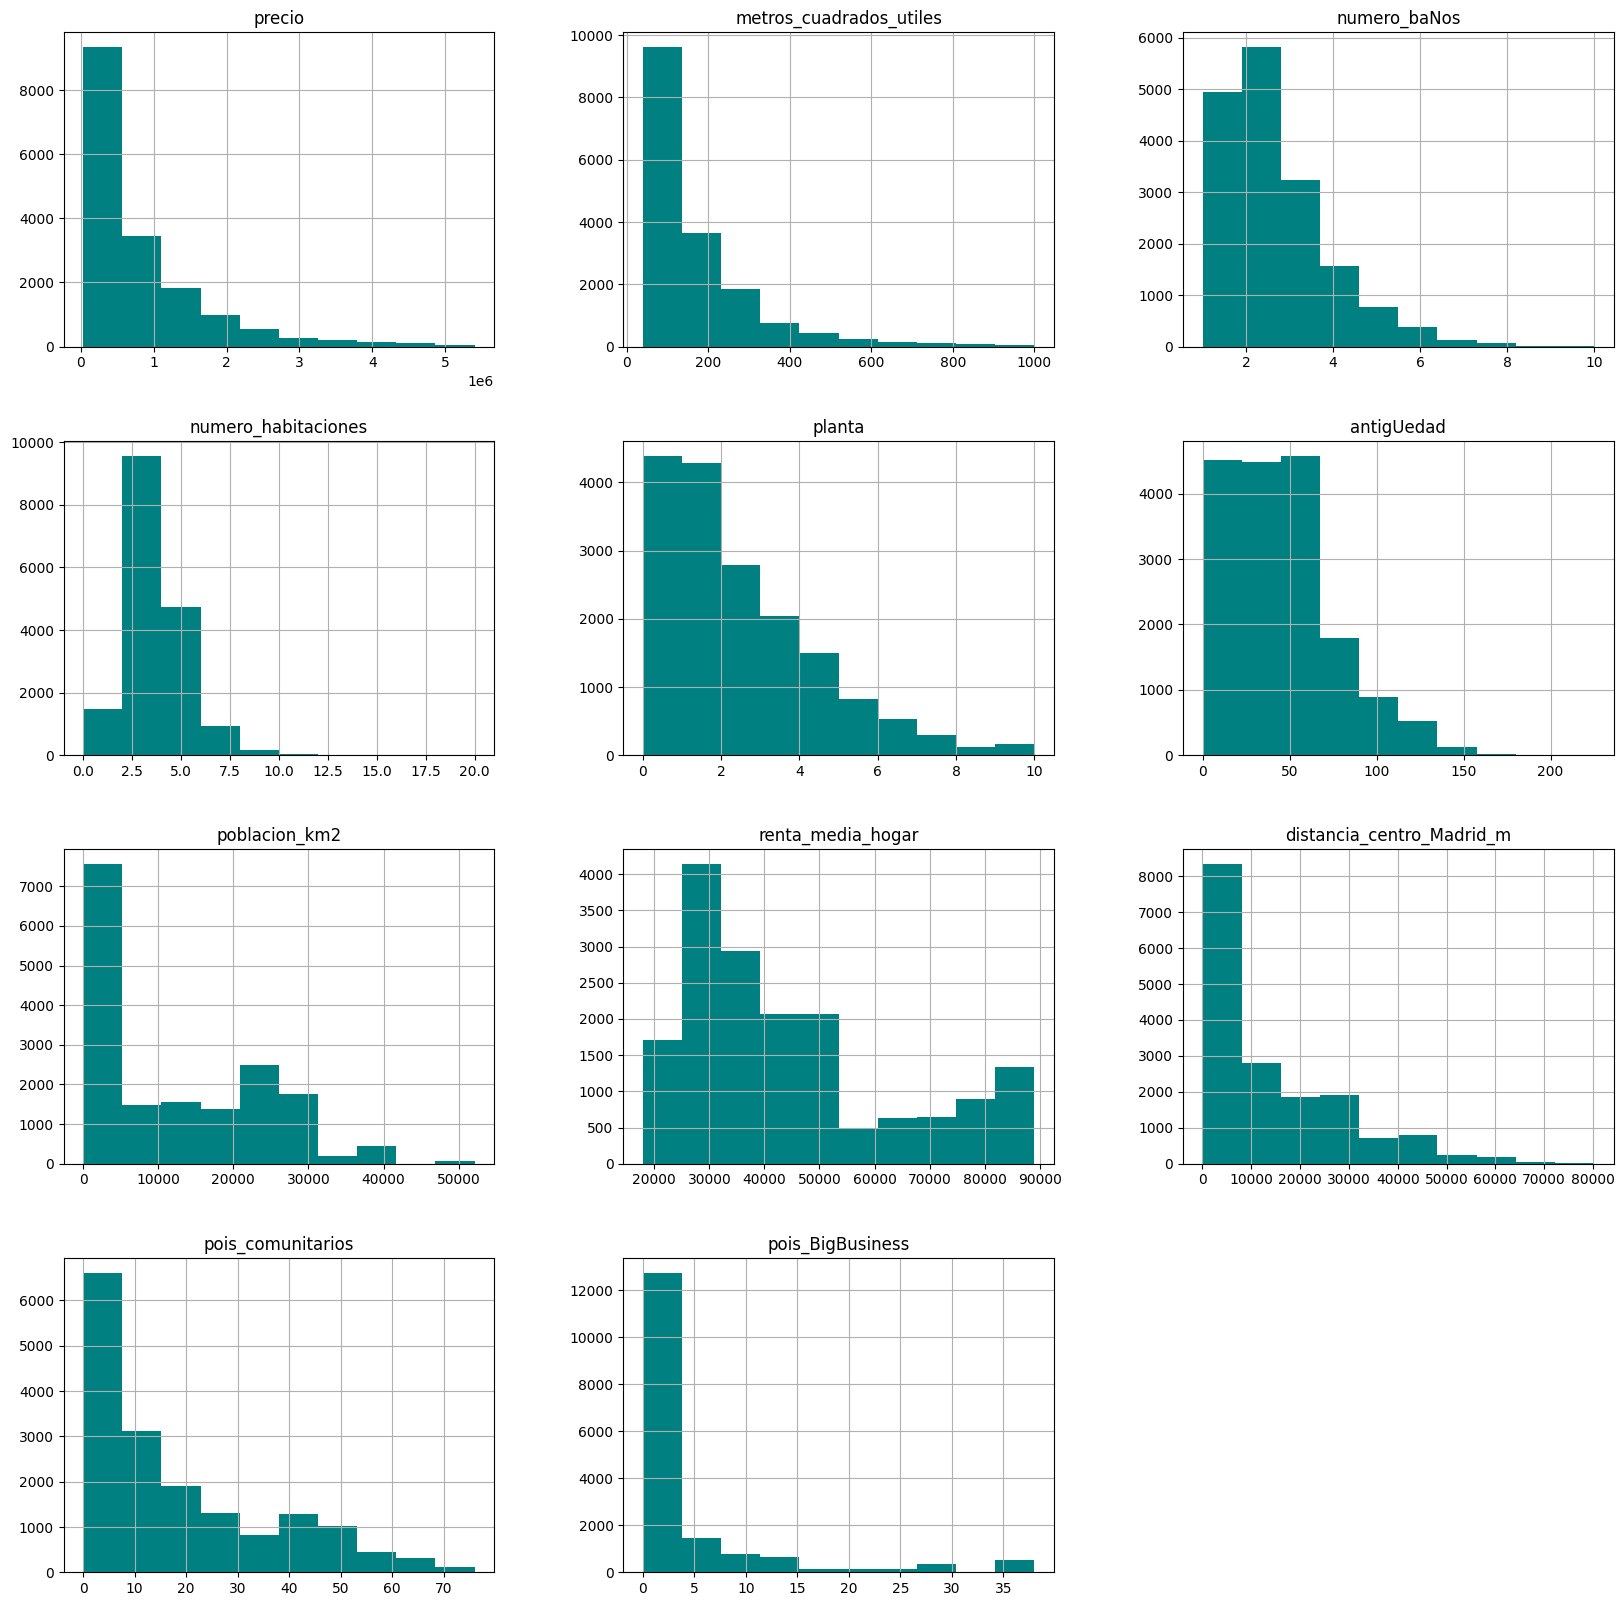

In [103]:
# Pintamos el histograma de cada variable por si se escapa algun outlier
datos_def.hist(figsize = (20,20), color="#008080")

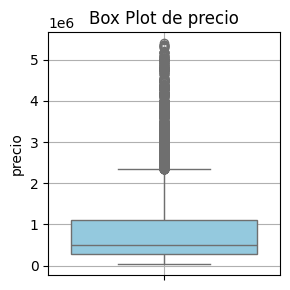

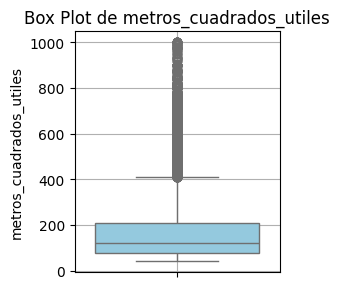

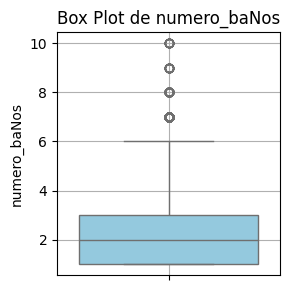

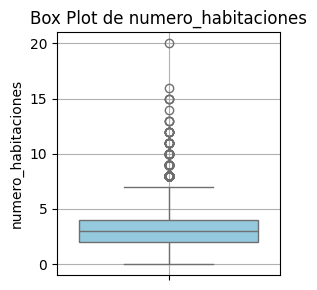

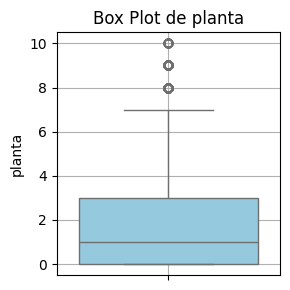

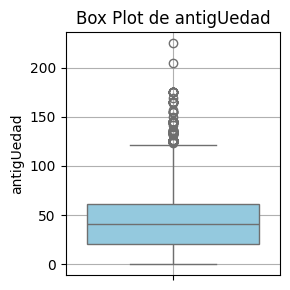

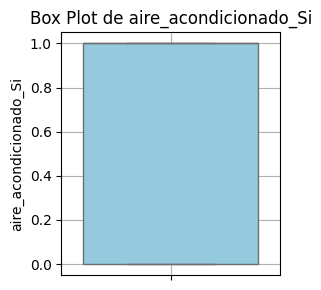

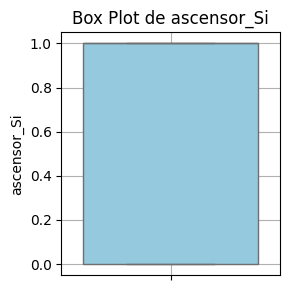

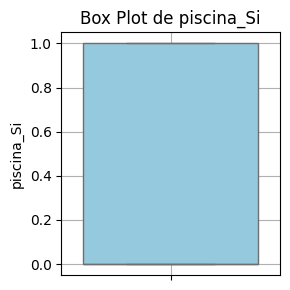

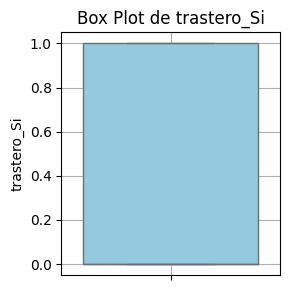

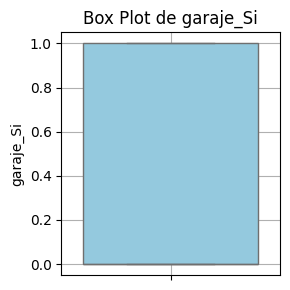

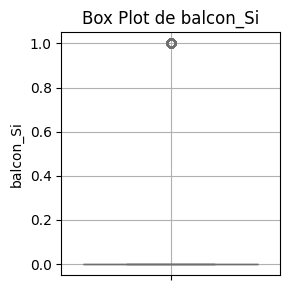

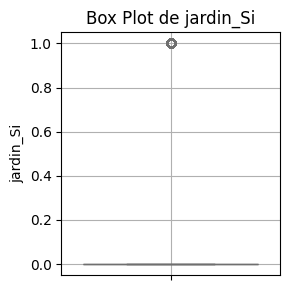

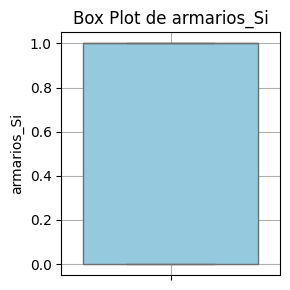

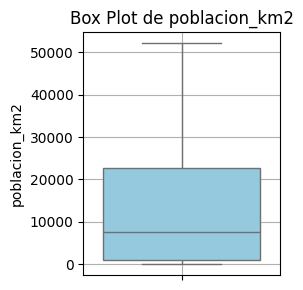

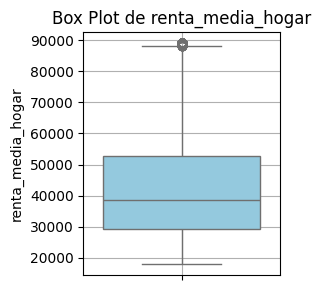

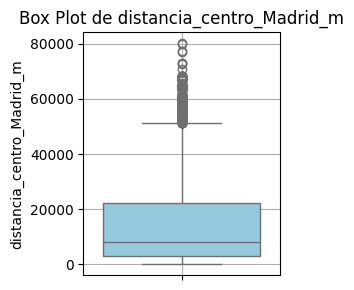

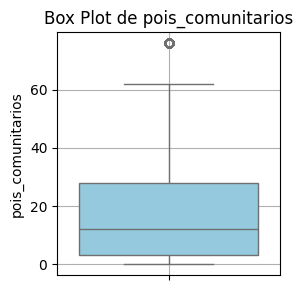

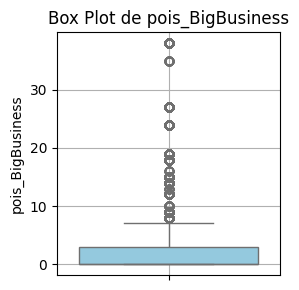

In [104]:
# Veamos ahora los diagramas de bigotes para cada variable.
# Pintamos el diagrama de bigotes de cada variable por si se escapa algun outlier
for var in datos_def.columns:
    plt.figure(figsize=(3, 3))
    sns.boxplot(y=var, data=datos_def, color='skyblue')
    plt.title(f'Box Plot de {var}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [105]:
# Veamos la correlación entre todas las variables. 
correlations = datos_def.corr()
print(correlations)

                             precio  metros_cuadrados_utiles  numero_baNos  \
precio                     1.000000                 0.556015      0.613824   
metros_cuadrados_utiles    0.556015                 1.000000      0.797879   
numero_baNos               0.613824                 0.797879      1.000000   
numero_habitaciones        0.342469                 0.703889      0.692212   
planta                     0.163988                -0.178120     -0.105788   
antigUedad                 0.178632                -0.149159     -0.129487   
aire_acondicionado_Si      0.229383                 0.065024      0.157596   
ascensor_Si                0.178535                -0.322013     -0.189846   
piscina_Si                 0.067862                 0.372722      0.353826   
trastero_Si                0.126275                 0.285971      0.291184   
garaje_Si                  0.115029                 0.350809      0.365361   
balcon_Si                  0.144658                 0.140751    

In [106]:
print(correlations["precio"])


precio                       1.000000
metros_cuadrados_utiles      0.556015
numero_baNos                 0.613824
numero_habitaciones          0.342469
planta                       0.163988
antigUedad                   0.178632
aire_acondicionado_Si        0.229383
ascensor_Si                  0.178535
piscina_Si                   0.067862
trastero_Si                  0.126275
garaje_Si                    0.115029
balcon_Si                    0.144658
jardin_Si                    0.074497
armarios_Si                  0.135491
poblacion_km2                0.170949
renta_media_hogar            0.593552
distancia_centro_Madrid_m   -0.314195
pois_comunitarios            0.329736
pois_BigBusiness             0.476828
Name: precio, dtype: float64


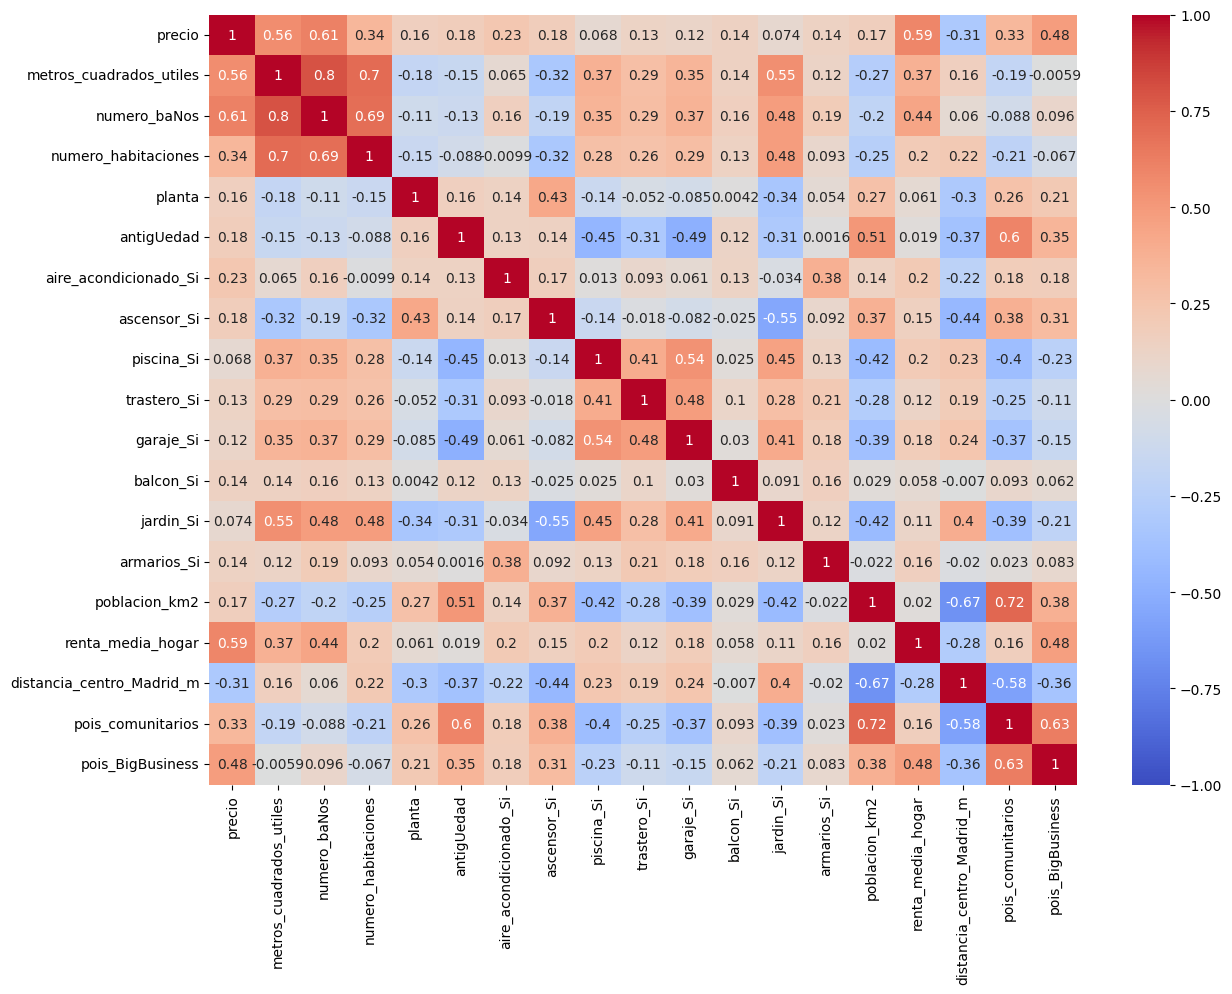

In [107]:
# Gráfico con la matriz de correlación entre todas las variables.
plt.figure(figsize=(14,10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

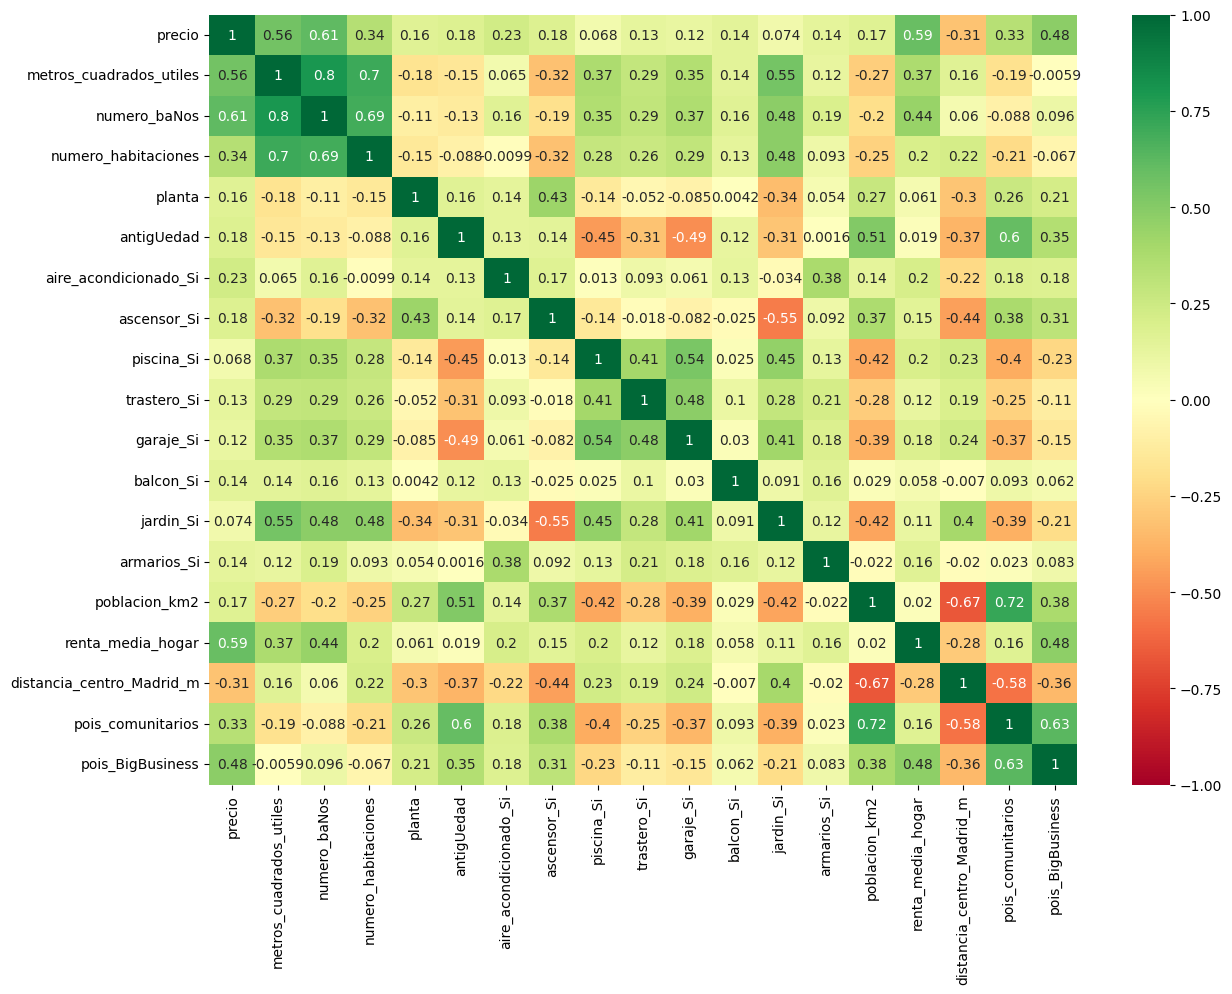

In [108]:
# Otro Gráfico con la matriz de correlación entre todas las variables.
plt.figure(figsize=(14,10))
sns.heatmap(correlations, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.show()

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_35476/2785882188.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")


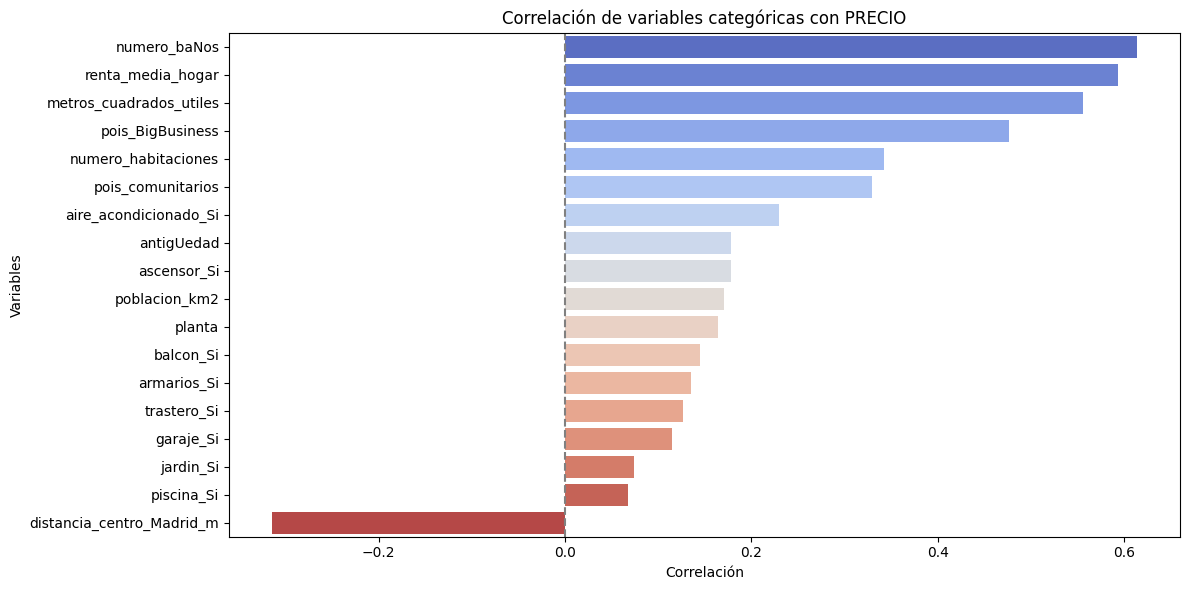

In [109]:
datos_sin_precio = datos_def.drop('precio', axis=1)
correlaciones = datos_sin_precio.corrwith(datos_def["precio"]).sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")
plt.title(f'Correlación de variables categóricas con PRECIO')
plt.xlabel('Correlación')
plt.ylabel('Variables')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

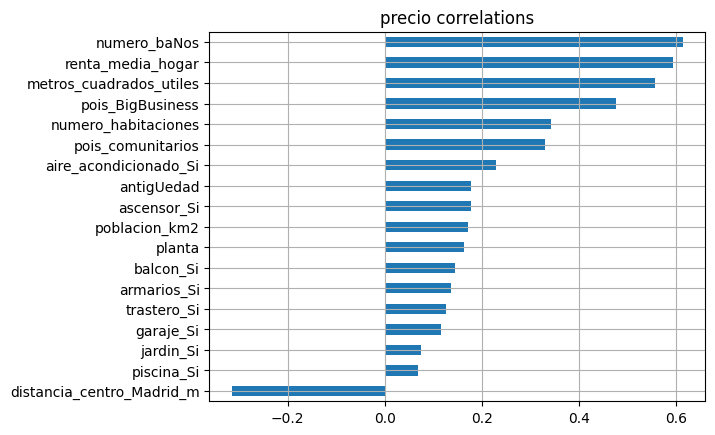

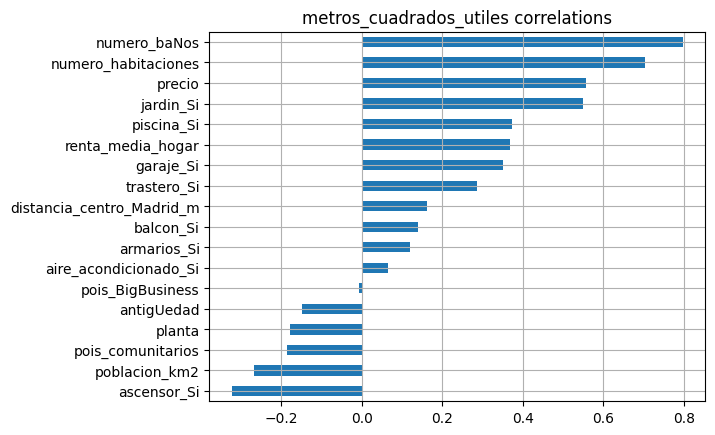

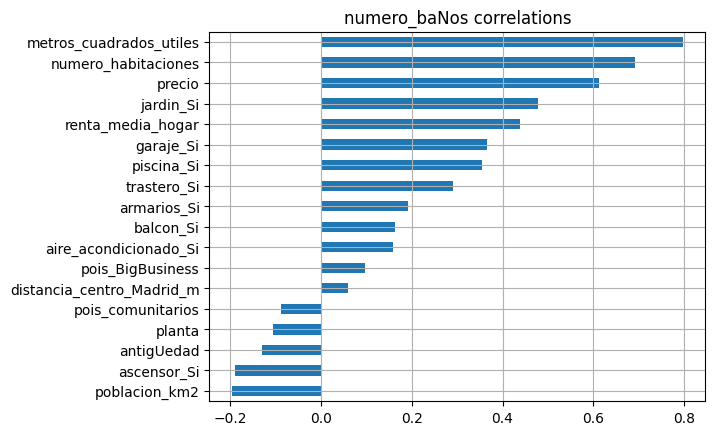

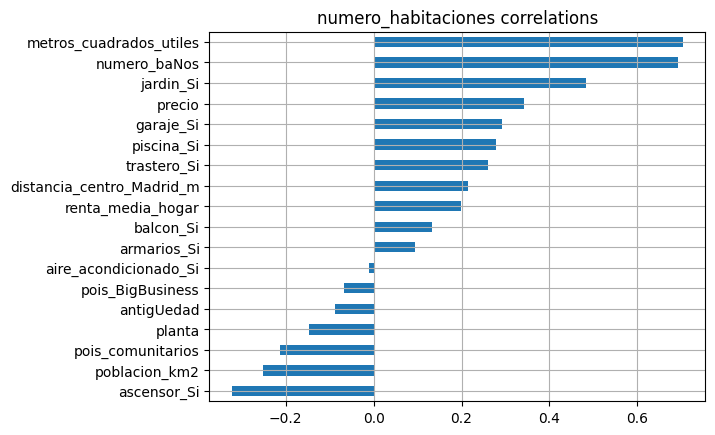

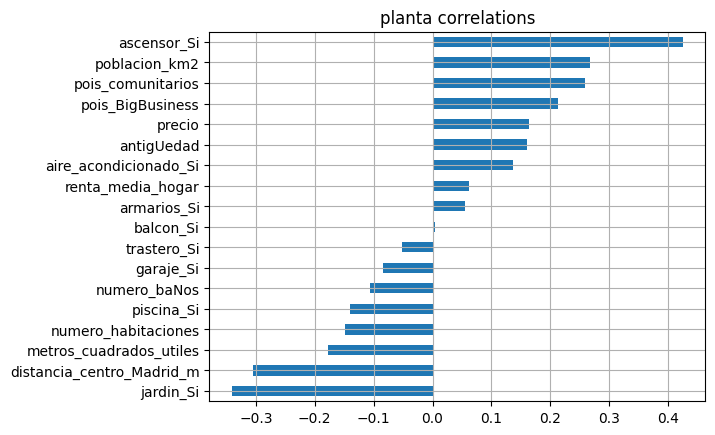

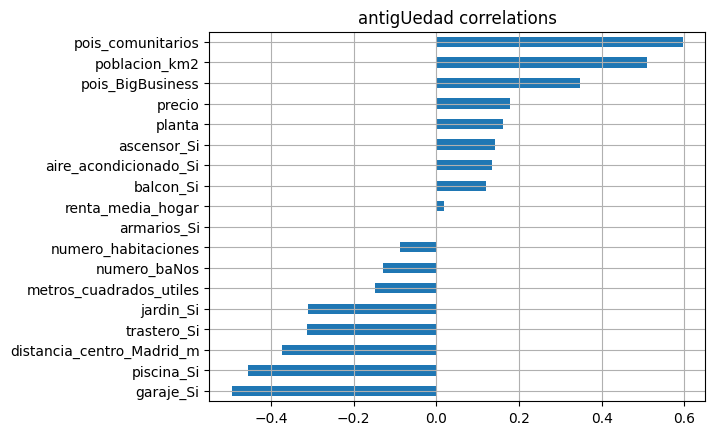

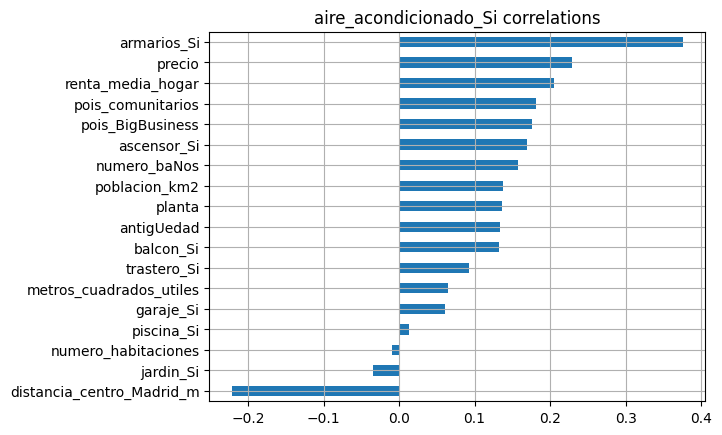

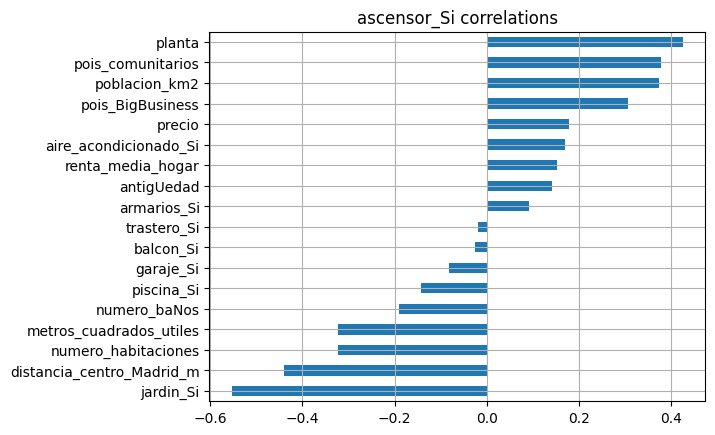

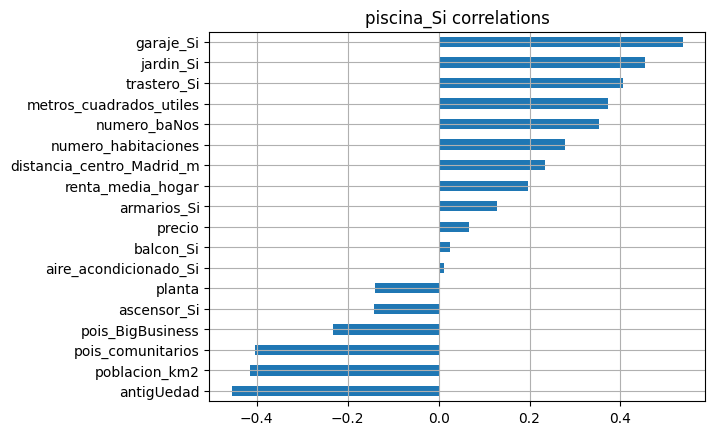

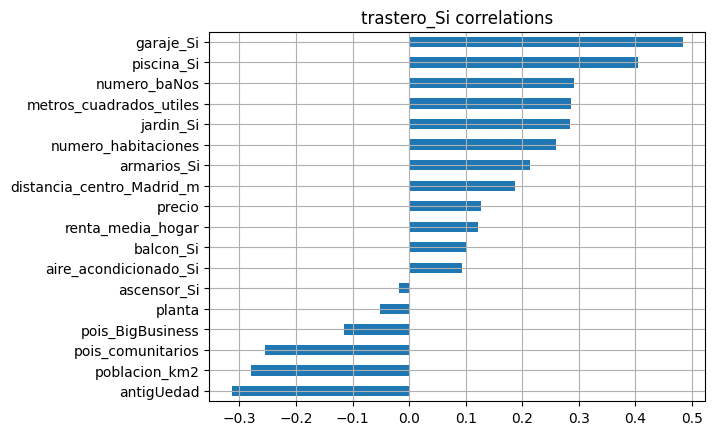

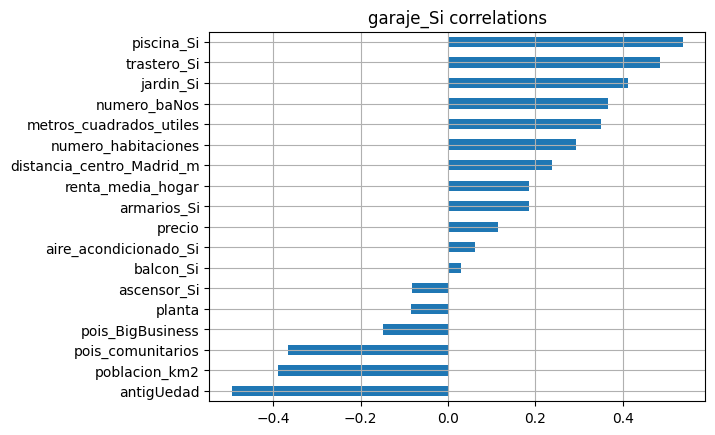

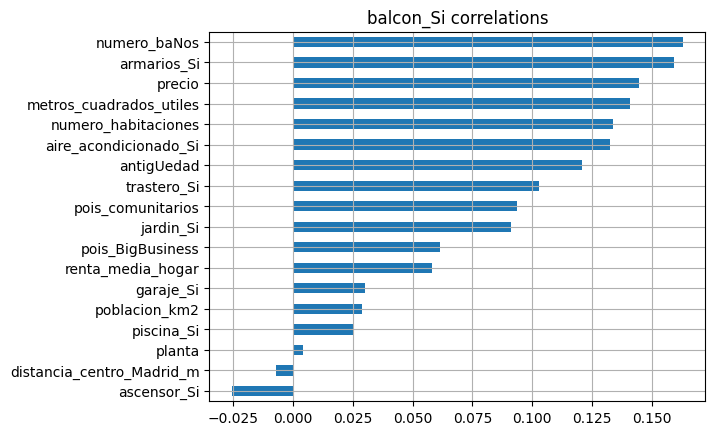

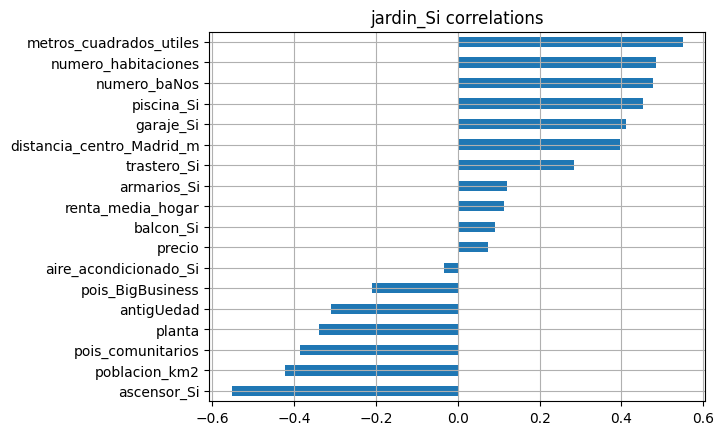

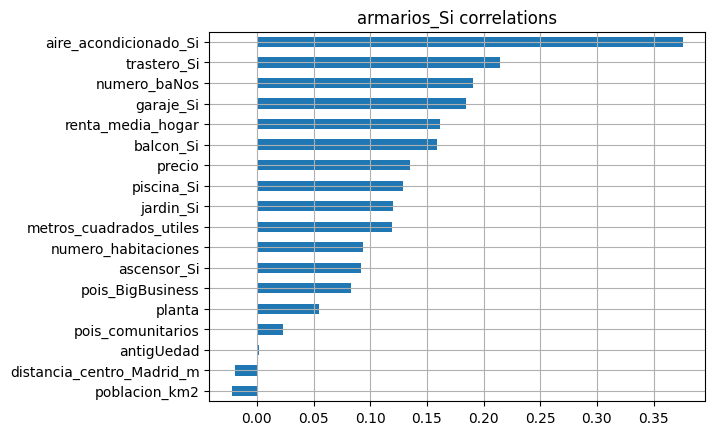

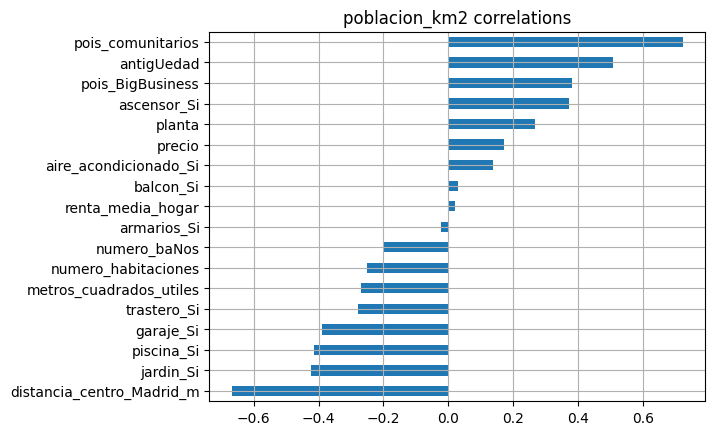

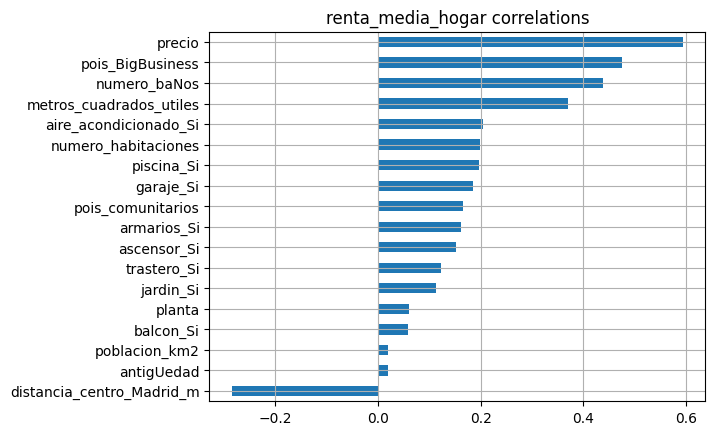

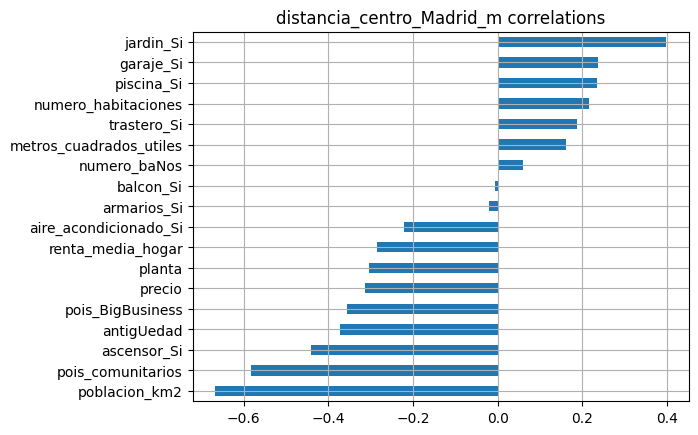

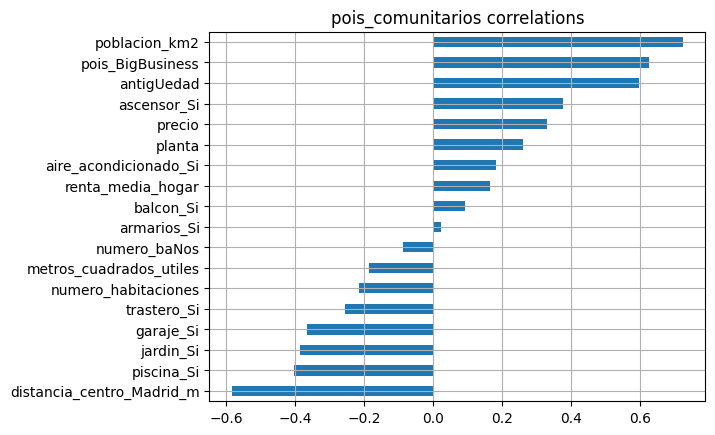

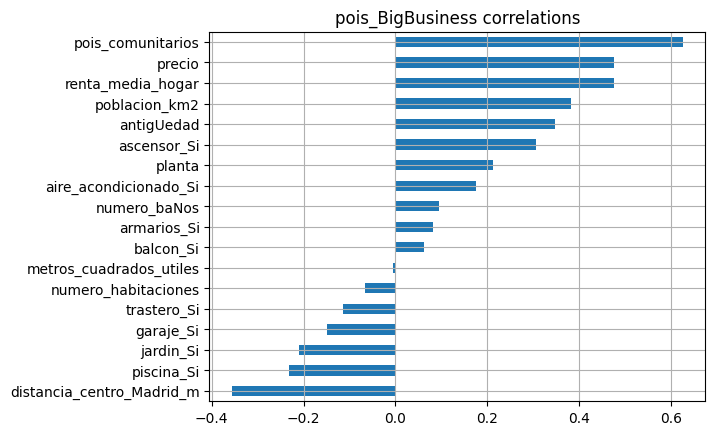

In [110]:
for var in datos_def.columns:
    (correlations[var].sort_values(ascending=True).drop(var).plot.barh(title=f'{var} correlations', grid=True));
    plt.show()

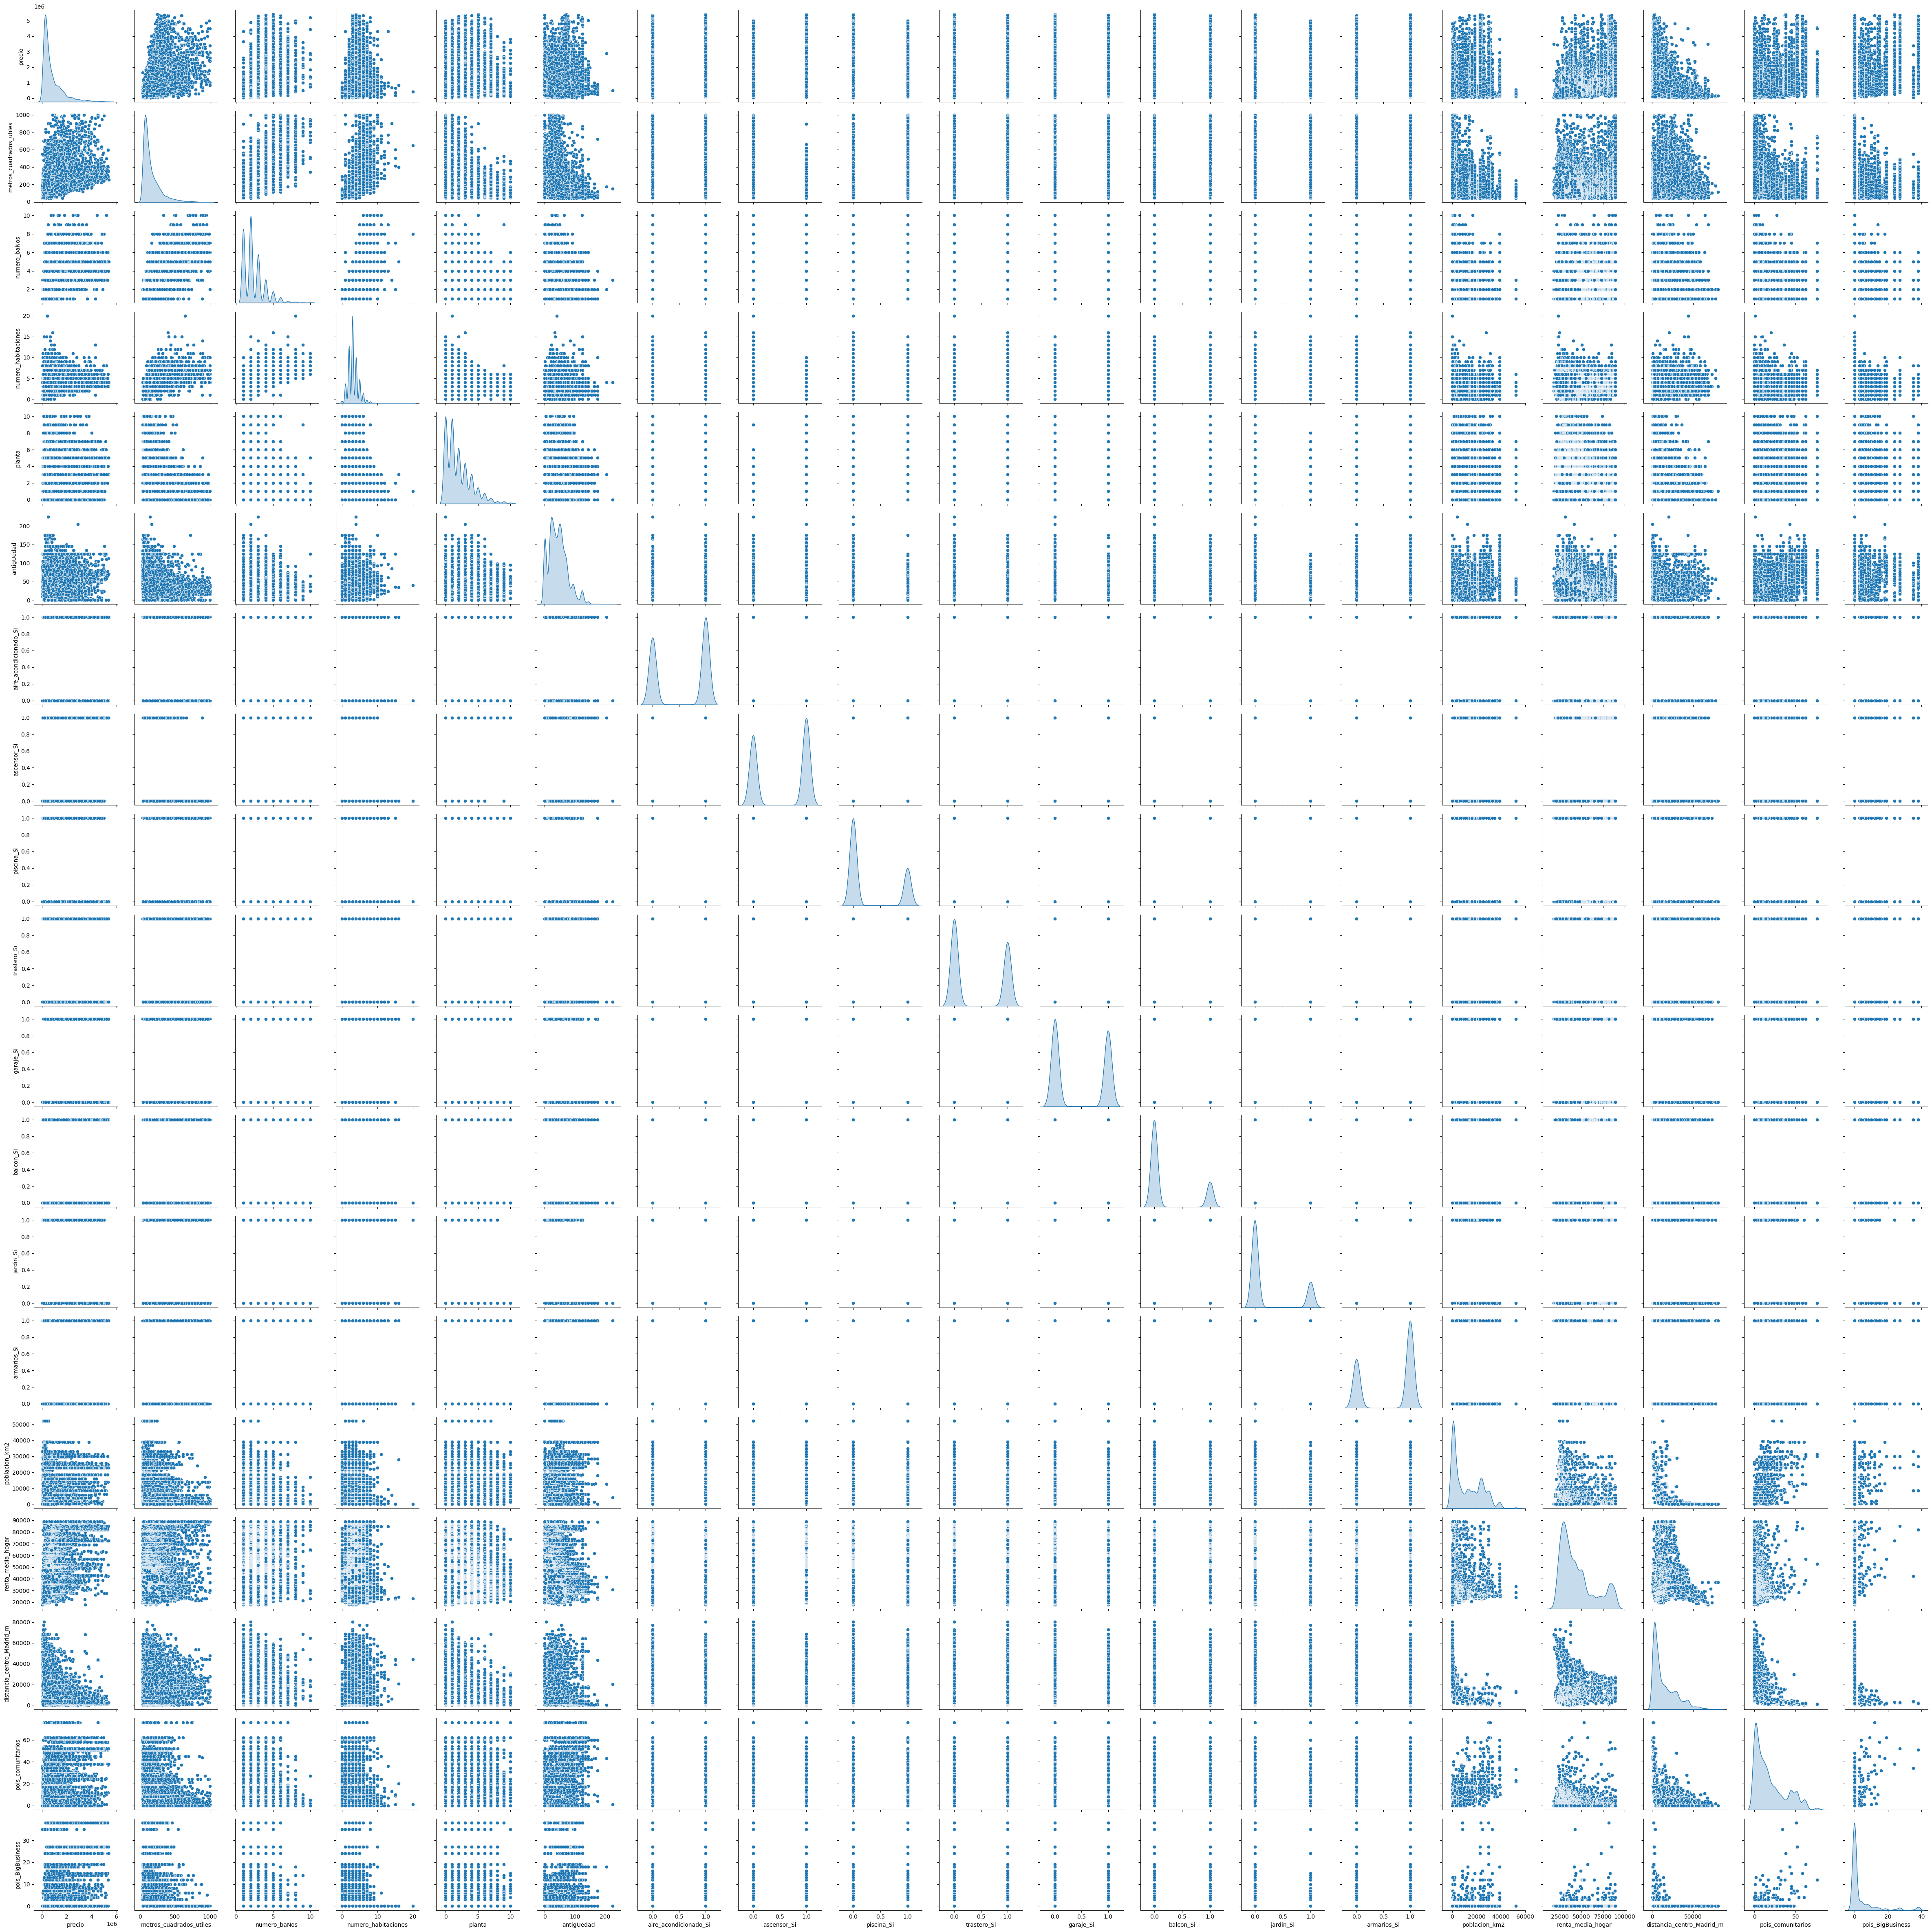

In [111]:
sns.pairplot(data=datos_def, diag_kind='kde', height=2.5)
plt.tight_layout()
plt.show()

In [146]:

#Correlacion de Spearman

corr_spearman = datos_def.corr(method='spearman')

print(corr_spearman)

                             precio  metros_cuadrados_utiles  numero_baNos  \
precio                     1.000000                 0.637146      0.674139   
metros_cuadrados_utiles    0.637146                 1.000000      0.825822   
numero_baNos               0.674139                 0.825822      1.000000   
numero_habitaciones        0.385782                 0.771384      0.678620   
planta                     0.164838                -0.153044     -0.108945   
antigUedad                 0.157333                -0.155436     -0.154971   
aire_acondicionado_Si      0.311823                 0.093447      0.173366   
ascensor_Si                0.244334                -0.226265     -0.128906   
piscina_Si                 0.174773                 0.348632      0.342002   
trastero_Si                0.174667                 0.336482      0.309807   
garaje_Si                  0.208624                 0.411697      0.401323   
balcon_Si                  0.181061                 0.170225    

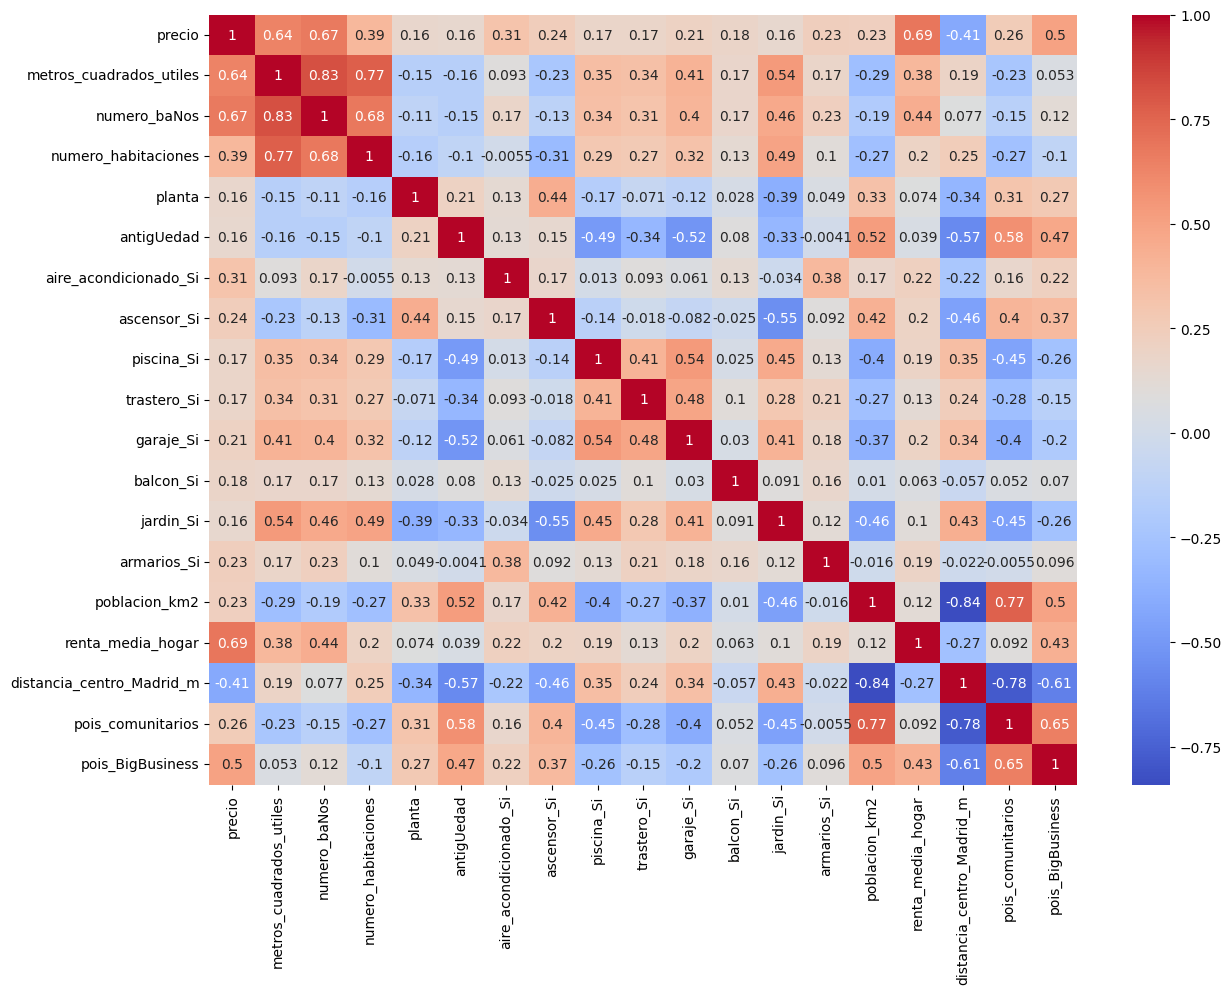

In [148]:

# Gráfico con la matriz de correlación entre todas las variables.
plt.figure(figsize=(14,10))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm')
plt.show()

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_35476/667245684.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")


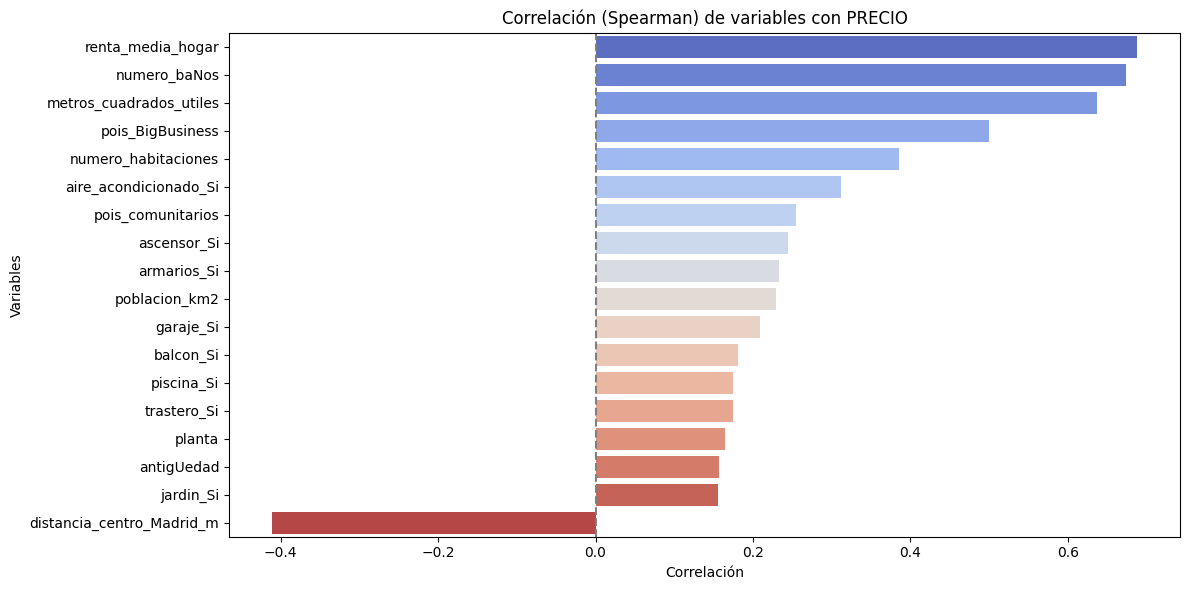

In [150]:

datos_sin_precio = datos_def.drop('precio', axis=1)

correlaciones = datos_sin_precio.corrwith(
    datos_def["precio"], 
    method='spearman'
).sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette="coolwarm")
plt.title('Correlación (Spearman) de variables con PRECIO')
plt.xlabel('Correlación')
plt.ylabel('Variables')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

VEAMOS LA CORRELACION DE LA VARIABLE OBJTEIVO ÚNICAMENTE CON LAS VARIABLES GEOESPACIALES

renta_media_hogar            0.687642
pois_BigBusiness             0.500388
pois_comunitarios            0.255162
poblacion_km2                0.229545
distancia_centro_Madrid_m   -0.410763
dtype: float64


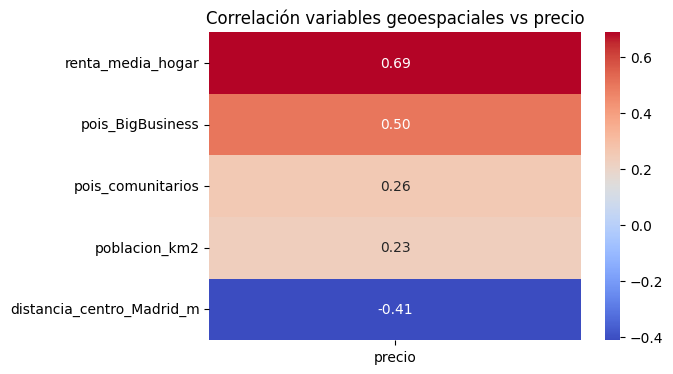

In [162]:
#SPEARMAN
variables_geo = ['precio', 'poblacion_km2', 'renta_media_hogar', 'distancia_centro_Madrid_m', 'pois_comunitarios','pois_BigBusiness']

df_geo = datos_def[variables_geo]
df_geo_d = df_geo.drop('precio', axis=1)

corr_matrix = df_geo_d.corrwith(
    df_geo["precio"],
    method='spearman'
).sort_values(ascending=False)

print(corr_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix.to_frame(name='precio'),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Correlación variables geoespaciales vs precio')
plt.show()

                             precio
precio                     1.000000
renta_media_hogar          0.593552
pois_BigBusiness           0.476828
pois_comunitarios          0.329736
poblacion_km2              0.170949
distancia_centro_Madrid_m -0.314195


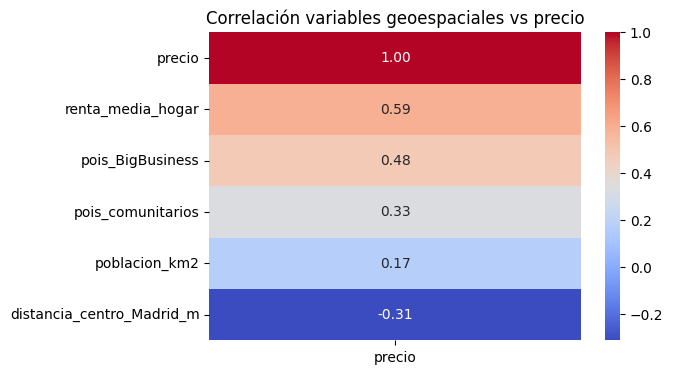

In [ ]:
#PEARSON
variables_geo = ['precio', 'poblacion_km2', 'renta_media_hogar', 'distancia_centro_Madrid_m', 'pois_comunitarios','pois_BigBusiness']

df_geo = datos_def[variables_geo]

# Calcular correlación
corr_matrix = df_geo.corr()

# Extraer solo correlación con el precio
corr_precio = corr_matrix[['precio']].sort_values(by='precio', ascending=False)

print(corr_precio)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(corr_precio, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación variables geoespaciales vs precio')
plt.show()

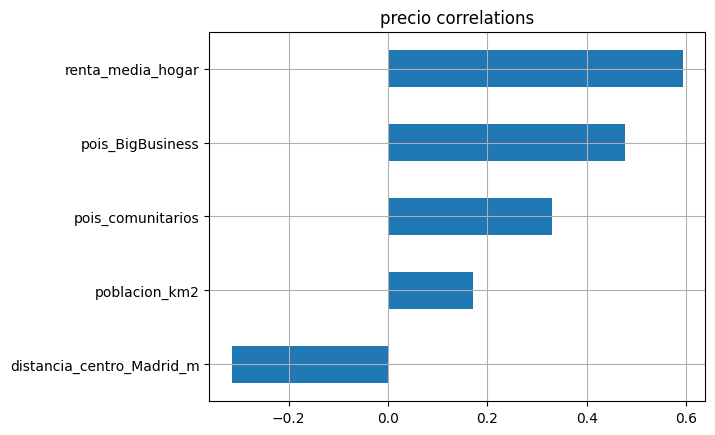

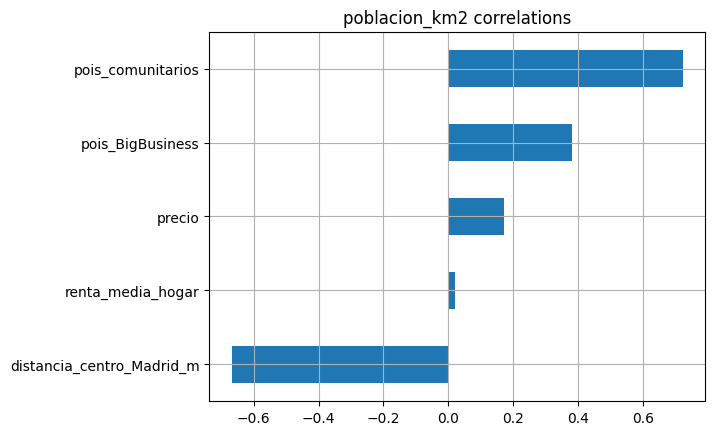

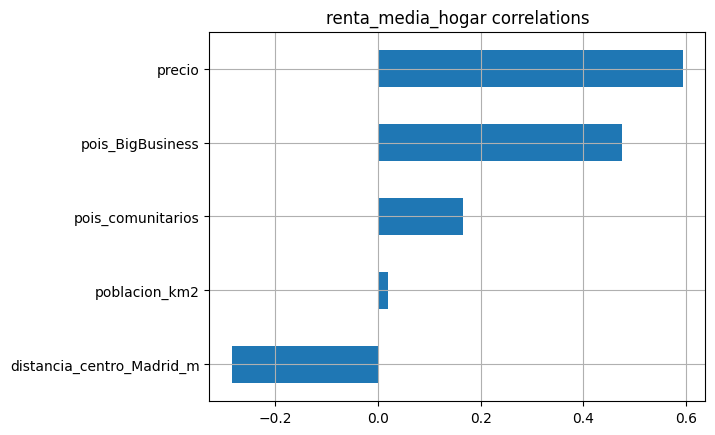

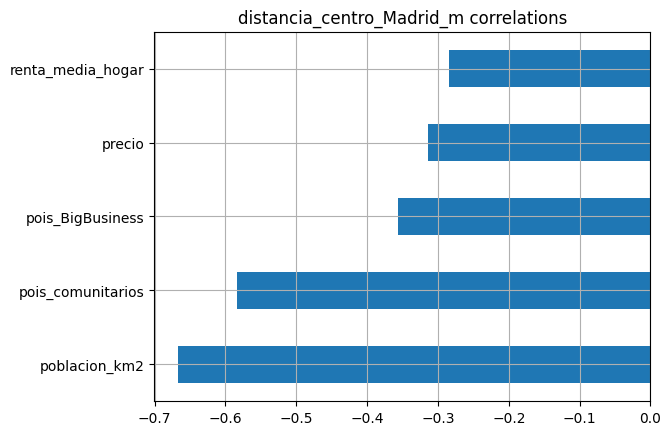

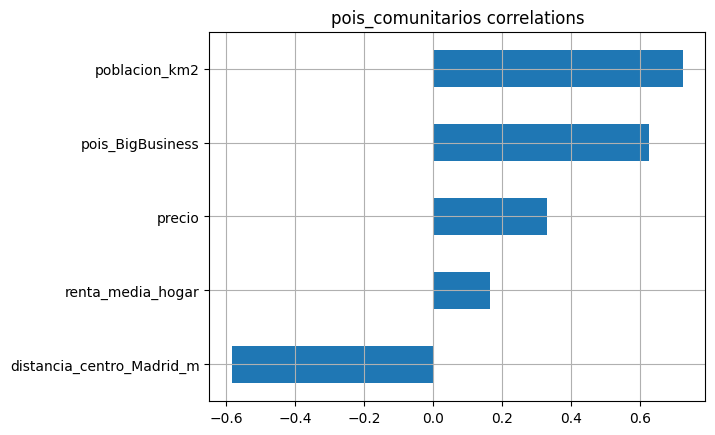

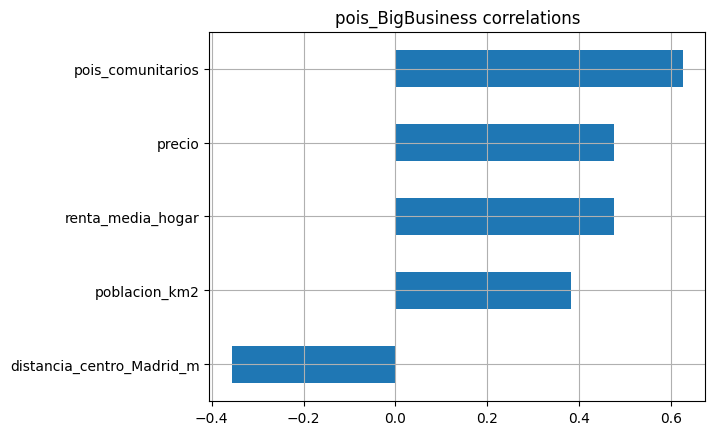

In [114]:
for var in df_geo.columns:
    (corr_matrix[var].sort_values(ascending=True).drop(var).plot.barh(title=f'{var} correlations', grid=True));
    plt.show()

                             precio  poblacion_km2  renta_media_hogar  \
precio                     1.000000       0.229545           0.687642   
poblacion_km2              0.229545       1.000000           0.117726   
renta_media_hogar          0.687642       0.117726           1.000000   
distancia_centro_Madrid_m -0.410763      -0.840802          -0.268402   
pois_comunitarios          0.255162       0.769361           0.091836   
pois_BigBusiness           0.500388       0.495409           0.431714   

                           distancia_centro_Madrid_m  pois_comunitarios  \
precio                                     -0.410763           0.255162   
poblacion_km2                              -0.840802           0.769361   
renta_media_hogar                          -0.268402           0.091836   
distancia_centro_Madrid_m                   1.000000          -0.776738   
pois_comunitarios                          -0.776738           1.000000   
pois_BigBusiness                      

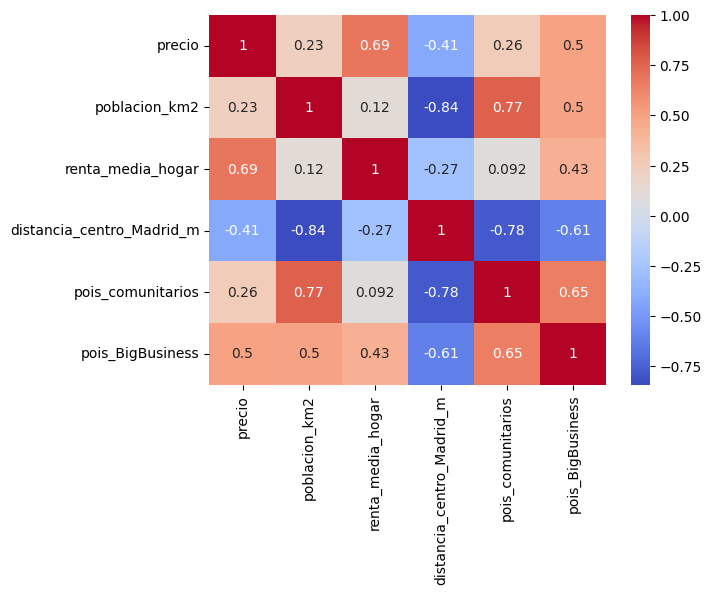

In [151]:
#Correlacion de Spearman

corr_spearman = df_geo.corr(method='spearman')

print(corr_spearman)

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm')
plt.show()

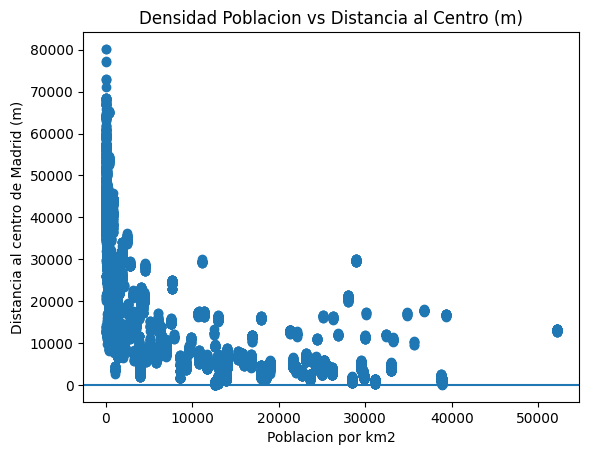

In [166]:

plt.figure()
plt.scatter(df_geo['poblacion_km2'], df_geo['distancia_centro_Madrid_m'])
plt.axhline(y=0)  # línea horizontal en 0
plt.xlabel("Poblacion por km2")
plt.ylabel("Distancia al centro de Madrid (m)")
plt.title("Densidad Poblacion vs Distancia al Centro (m)")
plt.show()

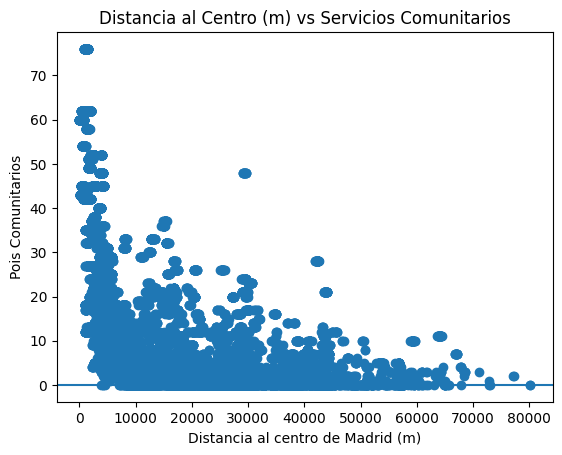

In [167]:
plt.figure()
plt.scatter(df_geo['distancia_centro_Madrid_m'], df_geo['pois_comunitarios'])
plt.axhline(y=0)  # línea horizontal en 0
plt.xlabel("Distancia al centro de Madrid (m)")
plt.ylabel("Pois Comunitarios")
plt.title("Distancia al Centro (m) vs Servicios Comunitarios")
plt.show()

**Aplicación PCA**

In [115]:
# Estandarizamos/Normalizamos
from sklearn.preprocessing import StandardScaler

data_norm =  StandardScaler().fit_transform(datos_sin_precio)
pd.DataFrame(data_norm).describe().T

,count,mean,std,min,25%,50%,75%,max
0,16923.0,-2.015367e-17,1.00003,-0.903522,-0.638935,-0.353459,0.280157,5.780781
1,16923.0,-4.702522e-17,1.00003,-1.003741,-1.003741,-0.276774,0.450193,5.538959
2,16923.0,8.061467e-17,1.00003,-2.150778,-0.816432,-0.149259,0.517913,11.192678
3,16923.0,6.381995e-17,1.00003,-1.010554,-1.010554,-0.503494,0.510625,4.060044
4,16923.0,-1.074862e-16,1.00003,-1.416670,-0.741242,-0.097978,0.545286,5.820054
5,16923.0,1.595499e-17,1.00003,-1.140426,-1.140426,0.876865,0.876865,0.876865
6,16923.0,6.717889e-17,1.00003,-1.115940,-1.115940,0.896105,0.896105,0.896105
7,16923.0,-2.687156e-17,1.00003,-0.655676,-0.655676,-0.655676,1.525143,1.525143
8,16923.0,-1.679472e-16,1.00003,-0.855237,-0.855237,-0.855237,1.169267,1.169267
9,16923.0,-2.351261e-17,1.00003,-0.933041,-0.933041,-0.933041,1.071765,1.071765


(16923, 18)
[0.290463   0.4553035  0.55085336 0.6182332  0.66910486 0.7153615
 0.75751262 0.7951066  0.82786407 0.85972432 0.88697774 0.91207534
 0.93362007 0.95085082 0.96657229 0.97948395 0.99009566 1.        ]


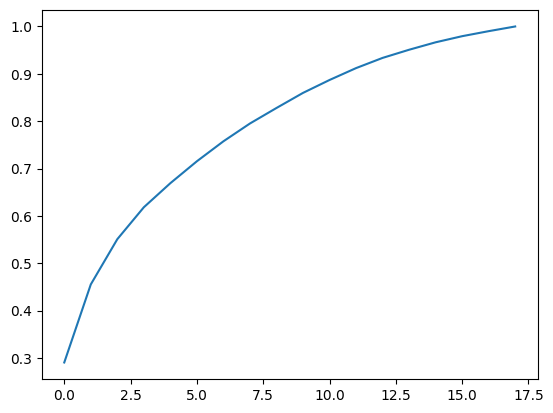

In [116]:
# Importamos el módulo que nos permite implementar el PCA
from sklearn.decomposition import PCA

# Veamos cuanta de la varianza es explicada por cada componente principal. Este PCA sería idéntico a escoger todas las variables ya que teníamos 11

pca_18 = PCA(18)
data_proj = pca_18.fit_transform(data_norm)
print(data_proj.shape)

cumvar = np.cumsum(pca_18.explained_variance_ratio_)
print(cumvar)
plt.plot(cumvar)

MODELOS - ML

# **APLICACIÓN DE MODELOS SUPERVISADOS PARA PREDECIR VARIABLE NUMÉRICA .**

In [117]:
# Para decidir que modelo escogemos, necesitamos poder testar con resultados que conocemos.

# Utilizamos la función train_test_split para dividir en datos de entrada y de salida tanto para entrenamiento como para test.
# La partición será de 70-30 para entrenamiento y test respectivamente.
# Como los datos están ordenados por fecha y ciudad, hay que barajarlos para no añadir sesgos al modelo, por ello indicamos el parámetro "shuffle = True".
# Con el fin de poder testar diferentes modelos con la misma distribución entrenamiento-test fijamos la semilla "random_state = 99".
# X=datos_sin_precio, Y=datos_def['precio']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(datos_sin_precio, datos_def['precio'], train_size= 0.8, random_state=99, shuffle=True)

X_train.head()

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,aire_acondicionado_Si,ascensor_Si,piscina_Si,trastero_Si,garaje_Si,balcon_Si,jardin_Si,armarios_Si,poblacion_km2,renta_media_hogar,distancia_centro_Madrid_m,pois_comunitarios,pois_BigBusiness
id,,,,,,,,,,,,,,,,,,
17714,270,2,3,1,75,True,False,False,True,False,False,True,False,103,23109,39286,1,0
12035,112,2,4,2,20,False,True,False,True,True,True,False,True,5075,26261,7680,9,0
1852,101,2,2,1,0,True,True,False,True,True,True,False,False,697,40316,24477,1,0
1791,216,3,4,0,24,False,False,True,True,True,False,True,True,1312,28124,18540,9,0
12166,73,2,2,0,47,True,False,False,False,False,False,False,True,6160,24088,7548,15,0


In [118]:
# Estandarizamos/Normalizamos -> Solo aplica a las variables numéricas, las Dummies se quedan sin estandarizar ya que no es necesario.
from sklearn.preprocessing import StandardScaler


variables_numericas = [
    'metros_cuadrados_utiles',
    'numero_baNos',
    'numero_habitaciones',
    'planta',
    'antigUedad',
    'poblacion_km2',
    'renta_media_hogar',
    'distancia_centro_Madrid_m',
    'pois_comunitarios',
    'pois_BigBusiness'
]

variables_dummies = [
    'aire_acondicionado_Si',
    'ascensor_Si',
    'piscina_Si',
    'trastero_Si',
    'garaje_Si',
    'balcon_Si',
    'jardin_Si',
    'armarios_Si'
]

estandarizacion = StandardScaler()
X_train_num = estandarizacion.fit_transform(X_train[variables_numericas])
X_test_num = estandarizacion.transform(X_test[variables_numericas])

X_train_scaled = pd.DataFrame(X_train_num, columns=variables_numericas, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_num, columns=variables_numericas, index=X_test.index)

# Añadir dummies sin tocar
X_train_final = pd.concat([X_train_scaled, X_train[variables_dummies]], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test[variables_dummies]], axis=1)

pd.DataFrame(X_train_final, columns=X_train_final.columns.values).describe()

#print(X_train_final.head(5))

,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,poblacion_km2,renta_media_hogar,distancia_centro_Madrid_m,pois_comunitarios,pois_BigBusiness
count,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04,1.353800e+04
mean,-9.893434e-17,2.033796e-17,2.204372e-17,1.180914e-17,-4.828625e-17,3.201589e-17,3.017891e-17,-6.823058e-17,-2.335585e-17,-2.361828e-18
std,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00,1.000037e+00
min,-9.075430e-01,-1.005457e+00,-2.156811e+00,-1.010897e+00,-1.419921e+00,-1.024933e+00,-1.375308e+00,-1.001792e+00,-9.982947e-01,-4.374580e-01
25%,-6.416726e-01,-1.005457e+00,-8.184553e-01,-1.010897e+00,-7.446213e-01,-9.350557e-01,-7.861010e-01,-7.852023e-01,-8.349534e-01,-4.374580e-01
50%,-3.548125e-01,-2.794904e-01,-1.492774e-01,-5.040632e-01,-6.932145e-02,-3.711407e-01,-3.166807e-01,-4.328585e-01,-3.449295e-01,-4.374580e-01
75%,2.818770e-01,4.464767e-01,5.199005e-01,5.096040e-01,5.416641e-01,9.214642e-01,4.349549e-01,5.600513e-01,5.806712e-01,-7.853759e-02
max,5.809182e+00,5.528246e+00,1.122675e+01,4.057439e+00,5.815434e+00,3.436827e+00,2.263749e+00,4.651718e+00,3.139685e+00,4.108867e+00


# **1 - MODELOS LINEALES**

## **Regresión Lineal Multivariante.**

In [119]:
from sklearn.linear_model import LinearRegression
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train_final, y_train)

# Predecimos
y_pred_regresion = modelo_regresion.predict(X_test_final)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_regresion)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_regresion))
r2 = r2_score(y_test, y_pred_regresion)
mape = np.mean(np.abs((y_test - y_pred_regresion) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 299,026 €
RMSE: 462,147 €
R²: 0.70
MAPE: 56.50%


In [120]:
#MOSTRAMOS LOS COEFICIENTES

# Recuperar desviación estándar de cada variable
stds = estandarizacion.scale_

# Coeficientes originales
coef = modelo_regresion.coef_

coef_num = coef[:len(variables_numericas)]
coef_dummy = coef[len(variables_numericas):]

stds = estandarizacion.scale_
means = estandarizacion.mean_

coef_num_original = coef_num / stds

# Ajustar intercepto a escala original
intercepto_original = modelo_regresion.intercept_ - np.sum(coef_num_original * means)

coeficientes = pd.DataFrame({
    'Variable': variables_numericas + variables_dummies,
    'Coeficiente (€ por unidad)': np.concatenate([coef_num_original, coef_dummy])
}).sort_values(by='Coeficiente (€ por unidad)', ascending=False)

print(coeficientes)
print("Intercepto original:", intercepto_original)

                     Variable  Coeficiente (€ por unidad)
1                numero_baNos               206389.262129
11                ascensor_Si               198406.537677
13                trastero_Si                60084.268551
3                      planta                32908.516110
15                  balcon_Si                28636.669555
9            pois_BigBusiness                18156.106895
10      aire_acondicionado_Si                17527.869008
14                  garaje_Si                 9624.028412
8           pois_comunitarios                 4321.588647
0     metros_cuadrados_utiles                 2493.764780
4                  antigUedad                 1700.252400
6           renta_media_hogar                    7.602144
5               poblacion_km2                   -0.421305
7   distancia_centro_Madrid_m                   -5.656766
2         numero_habitaciones               -42157.791813
17                armarios_Si               -56590.864734
12            

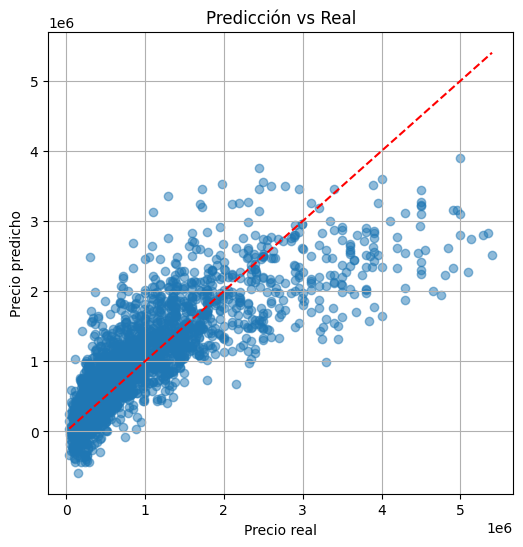

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_regresion, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Predicción vs Real")
plt.grid(True)
plt.show()

Predicciones demasiado dispersas, aunque para viviendas de menos de 2M los resUltados MAE no serían tan abultados.

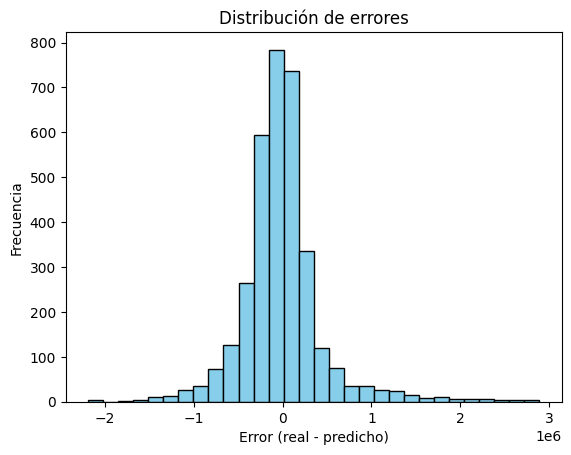

In [123]:
errors = y_test - y_pred_regresion
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de errores")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de valores tienen errores cercanos a 0, lo que afirma que pocas viviendas (las atípicas) distorsionan demasiado el modelo.

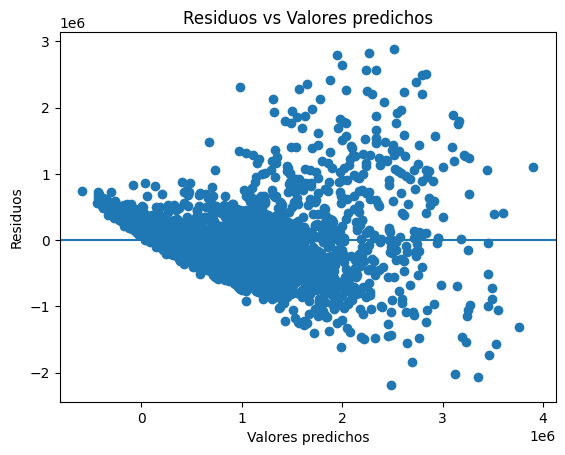

In [124]:

plt.figure()
plt.scatter(y_pred_regresion, errors)
plt.axhline(y=0)  # línea horizontal en 0
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores predichos")
plt.show()


Los residuos no están uniformemente distribuidos, lo que indica heterocedasticidad y limitaciones del modelo lineal.

-No está capturando completamente la relación entre las variables predictoras y el precio.

-Podría estar omitiendo variables importantes o está usando un modelo demasiado simple (como una regresión lineal cuando hay relaciones no lineales).

In [125]:
#PARA PODER OBTENER MÁS INFORMACIÓN DE LA REGRESIÓN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 1. División train-test
X_train, X_test, y_train, y_test = train_test_split(datos_sin_precio, datos_def['precio'], train_size=0.80, random_state=99, shuffle=True)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

# 2. Añadir constante
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# 3. Modelo
modelo = sm.OLS(y_train, X_train_const).fit()

# 4. Predicción
y_pred = modelo.predict(X_test_const)

# 5. Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

# 6. Coeficientes (interpretables directamente)
print("Intercepto:", modelo.params[0])
for param, coef in zip(X_train.columns, modelo.params[1:]):
    print(f"{param}: {coef}")

# 7. Summary completo
print(modelo.summary())

# 8. P-values
print(modelo.pvalues.sort_values())


MAE: 299,026 €
RMSE: 462,147 €
R²: 0.70
MAPE: 56.50%
Intercepto: -543208.5161553875
metros_cuadrados_utiles: 2493.76477981493
numero_baNos: 206389.2621287502
numero_habitaciones: -42157.79181290265
planta: 32908.516110388846
antigUedad: 1700.2524000109565
aire_acondicionado_Si: 17527.86900784898
ascensor_Si: 198406.53767718957
piscina_Si: -93231.4202058882
trastero_Si: 60084.2685507001
garaje_Si: 9624.028411688856
balcon_Si: 28636.669555240056
jardin_Si: -142698.48523070058
armarios_Si: -56590.8647336359
poblacion_km2: -0.4213054074165181
renta_media_hogar: 7.602143590167527
distancia_centro_Madrid_m: -5.6567661714616575
pois_comunitarios: 4321.588646594286
pois_BigBusiness: 18156.106895406174
                            OLS Regression Results                            
Dep. Variable:                 precio   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:        

/var/folders/jq/vg6hqkr57rbbsd6xq59b8l940000gn/T/ipykernel_35476/1153605629.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Intercepto:", modelo.params[0])


In [ ]:
#agregar AIC y BIC 

print("AIC:", modelo.aic)
print("BIC:", modelo.bic)
print("R² ajustado:", modelo.rsquared_adj)

AIC: 392201.92065348546
BIC: 392344.67251416174
R² ajustado: 0.6957899328153734


## **Regresión Polinomial**.

In [127]:
# Veamos si mejoramos el modelo aplicando un modelo de regresión polinómica de grado 3 para comprobar si se mejoran los resultados 
# y se captan mejor las relaciones "no-lineales" entre las variables predictoras y la variable objetivo (a predecir).
# He probado grado 2 y ya mejora, pero el grado que mejor MAE obtiene es grado 3. Para grado 4 o mayor los resultados empeoran exponencialmente.
from sklearn.preprocessing import PolynomialFeatures 

# usaremos todos los polinomios resultantes de grado 
polinomial = PolynomialFeatures(degree = 3,  include_bias=False)    

X_train_polinomial = polinomial.fit_transform(X_train_final)
X_test_polinomial = polinomial.transform(X_test_final)

modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_train_polinomial, y_train) #sin aplicar logaritmo sobre y_train

# Predecimos
y_pred_polinomial = modelo_polinomial.predict(X_test_polinomial)


mae = mean_absolute_error(y_test, y_pred_polinomial)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_polinomial))
r2 = r2_score(y_test, y_pred_polinomial)
mape = np.mean(np.abs((y_test - y_pred_polinomial) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 210,136 €
RMSE: 358,324 €
R²: 0.82
MAPE: 35.18%


## **RIDGE/LASSO**

In [128]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_final, y_train)
y_pred_ridge = ridge.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)
mape = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 299,014 €
RMSE: 462,144 €
R²: 0.70
MAPE: 56.49%


In [129]:
# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_final, y_train)
y_pred_lasso = lasso.predict(X_test_final)

mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2 = r2_score(y_test, y_pred_lasso)
mape = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 299,026 €
RMSE: 462,147 €
R²: 0.70
MAPE: 56.50%


## **2 - Modelos Basados en distancia**.

## **KNN Vecinos Más Cercanos**.

APLICAMOS GRID_SEARCH_CV PARA LA PARAMETRIZACION CORRECTA Y UTILIZAR VALIDACION CRUZADA.

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold

# =========================
# 0. ESTANDARIZACION POR TIPO DE VARIABLES
# =========================
preprocess = ColumnTransformer([
    ('num', StandardScaler(), variables_numericas),
    ('cat', 'passthrough', variables_dummies)
])

# =========================
# 1. PIPELINE (escala + modelo)
# =========================
pipe = Pipeline([
    ('preprocess', preprocess),
    ('knn', KNeighborsRegressor())
])

# =========================
# 2. GRID DE HIPERPARÁMETROS
# =========================
param_grid = {
    'knn__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 30],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski', 'manhattan', 'chebyshev', 'euclidean'],
    'knn__p': [1,2]
}

# =========================
# 3. VALIDACIÓN CRUZADA
# =========================
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# =========================
# 4. GRID SEARCH --> n_jobs es el numero de nucleos que se usa de mi computer (-1 son todos los disponibles)
# =========================
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# =========================
# 5. ENTRENAMIENTO
# =========================
grid_search.fit(X_train, y_train)

# Mejor modelo
best_knn = grid_search.best_estimator_

print("Mejores parámetros:", grid_search.best_params_)

# =========================
# 6. PREDICCIÓN FINAL
# =========================
y_pred_knn_ = best_knn.predict(X_test)

# =========================
# 7. MÉTRICAS
# =========================
mae = mean_absolute_error(y_test, y_pred_knn_)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn_))
r2 = r2_score(y_test, y_pred_knn_)
mape = np.mean(np.abs((y_test - y_pred_knn_) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

Mejores parámetros: {'knn__metric': 'minkowski', 'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'distance'}
MAE: 180,436 €
RMSE: 344,863 €
R²: 0.83
MAPE: 25.27%


## **3  - Modelos basados en árboles.**
## **Árboles de Decisión - Regresión.**

In [131]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=99)

param_grid = {
    'max_depth': [5,6, 7, 8, 9, 10, 10, 11, 12, 13, 14, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

cv = KFold(n_splits=10, shuffle=True, random_state=99)

grid_search_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search_tree.fit(X_train, y_train)

best_tree = grid_search_tree.best_estimator_

print("Mejores parámetros:", grid_search_tree.best_params_)

y_pred_tree = best_tree.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)
mape = np.mean(np.abs((y_test - y_pred_tree) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

Mejores parámetros: {'max_depth': 13, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
MAE: 208,694 €
RMSE: 375,147 €
R²: 0.80
MAPE: 31.56%


                      Feature  Importance
1                numero_baNos    0.339042
0     metros_cuadrados_utiles    0.217517
17           pois_BigBusiness    0.174885
15  distancia_centro_Madrid_m    0.162162
14          renta_media_hogar    0.040946
4                  antigUedad    0.025933
6                 ascensor_Si    0.013073
13              poblacion_km2    0.009964
16          pois_comunitarios    0.005049
3                      planta    0.004312
2         numero_habitaciones    0.002646
5       aire_acondicionado_Si    0.001006
10                  balcon_Si    0.000999
8                 trastero_Si    0.000968
11                  jardin_Si    0.000650
12                armarios_Si    0.000564
9                   garaje_Si    0.000157
7                  piscina_Si    0.000125


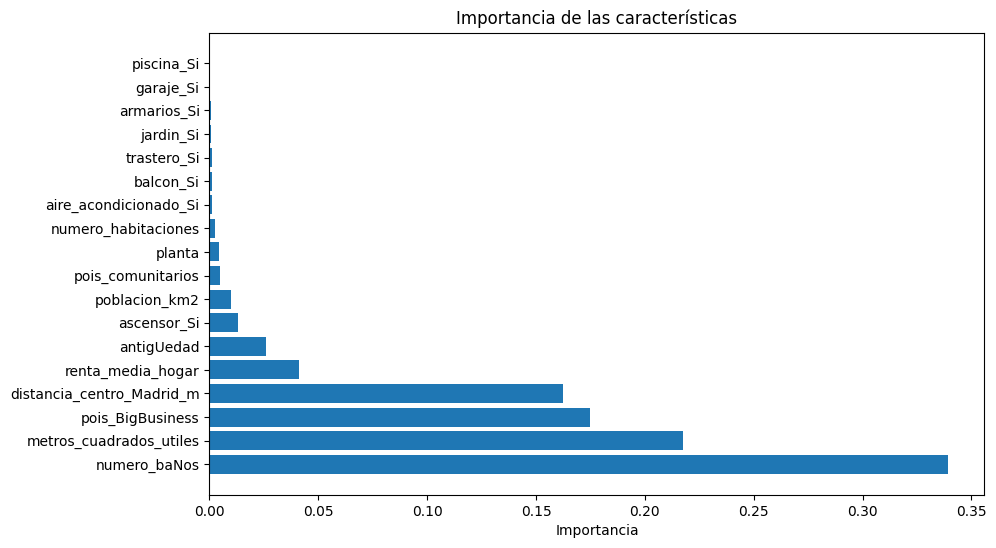

In [132]:
data_t = datos_sin_precio
data_l = datos_def['precio']

importances = best_tree.feature_importances_

# Crear un DataFrame para mostrar la importancia de cada característica
importance_df = pd.DataFrame({
    'Feature': data_t.columns,
    'Importance': importances
})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)


indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las características")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [data_t.columns[i] for i in indices])
plt.xlabel("Importancia")
plt.show()

## **4  - Modelos Ensemble.**

## **Random Forest.**

In [133]:

# Importamos el módulo para aplicar Árboles de Decisión.
from sklearn.ensemble import RandomForestRegressor

# Modelo base
rf = RandomForestRegressor(
    random_state=99,
    n_jobs=-1
)

# Grid de hiperparámetros
param_grid_rf = {
    'n_estimators': [10, 20, 50, 75, 100, 200, 300],
    'max_depth': [8, 10, 12, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# IMPORTANTE: entrenar con log
grid_search_rf.fit(X_train, np.log(y_train))

best_rf = grid_search_rf.best_estimator_

y_pred_rf = np.exp(best_rf.predict(X_test))


#Obtenemos los valores del mejor modelo
print("Parametros mejor modelo: ", grid_search_rf.best_params_)


# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# R2
r2_rf = r2_score(y_test, y_pred_rf)

# MAPE
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

# Mostrar resultados
print("Resultados Random Forest:")
print(f"MAE: {mae_rf:,.0f} €")
print(f"RMSE: {rmse_rf:,.0f} €")
print(f"R²: {r2_rf:.4f}")
print(f"MAPE: {mape_rf:.2f}%")

Parametros mejor modelo:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Resultados Random Forest:
MAE: 155,965 €
RMSE: 313,500 €
R²: 0.8605
MAPE: 21.11%


                      Feature  Importance
0     metros_cuadrados_utiles    0.202791
14          renta_media_hogar    0.191724
1                numero_baNos    0.161376
15  distancia_centro_Madrid_m    0.109345
17           pois_BigBusiness    0.075385
16          pois_comunitarios    0.047383
13              poblacion_km2    0.043886
2         numero_habitaciones    0.038196
4                  antigUedad    0.036512
6                 ascensor_Si    0.025158
3                      planta    0.016282
5       aire_acondicionado_Si    0.011578
9                   garaje_Si    0.009409
7                  piscina_Si    0.009246
11                  jardin_Si    0.007123
12                armarios_Si    0.006057
8                 trastero_Si    0.004914
10                  balcon_Si    0.003635


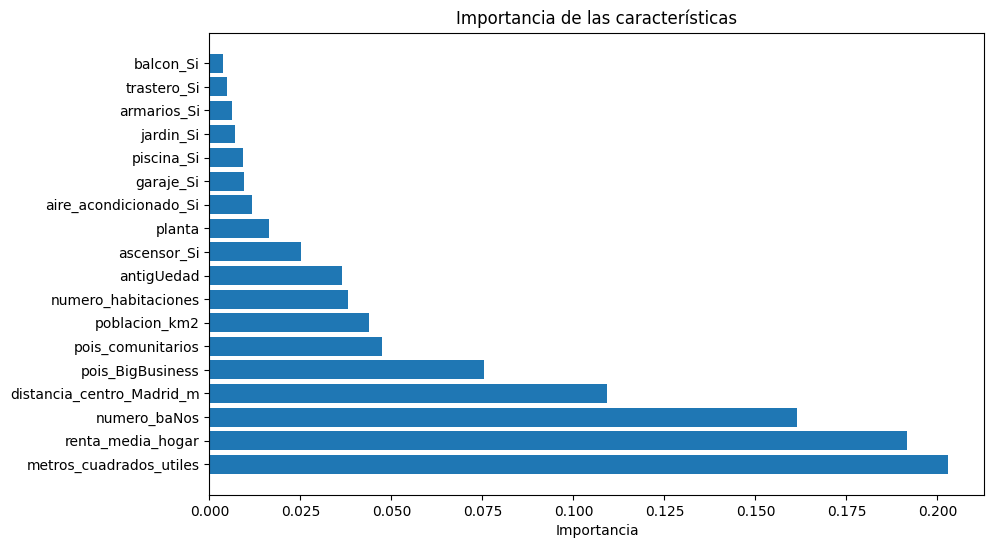

In [134]:
# Obtener la importancia de las características
importances = best_rf.feature_importances_

# Crear un DataFrame para mostrar la importancia de cada característica
importance_df = pd.DataFrame({
    'Feature': data_t.columns,
    'Importance': importances
})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Importancia de las características")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [data_t.columns[i] for i in indices])
plt.xlabel("Importancia")
plt.show()

## **Bagging**

In [135]:
from sklearn.ensemble import BaggingRegressor


# Modelo base (árbol sencillo)
base_tree = DecisionTreeRegressor(random_state=99)

# Modelo Bagging
bagging = BaggingRegressor(
    estimator=base_tree,
    random_state=99,
    n_jobs=-1
)

# Grid de hiperparámetros
param_grid_bagging = {
    'n_estimators': [10, 25, 50, 100, 150, 200, 300],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_bagging = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid_bagging,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Entrenamiento con log
grid_search_bagging.fit(X_train, np.log(y_train))


#MEJOR MODELO
best_bgg = grid_search_bagging.best_estimator_

y_pred_bgg = np.exp(best_bgg.predict(X_test))


#Obtenemos los valores del mejor modelo
print("Parametros mejor modelo: ", grid_search_bagging.best_params_)


# MAE
mae_bgg = mean_absolute_error(y_test, y_pred_bgg)

# RMSE
rmse_bgg = np.sqrt(mean_squared_error(y_test, y_pred_bgg))

# R2
r2_bgg = r2_score(y_test, y_pred_bgg)

# MAPE
mape_bgg = np.mean(np.abs((y_test - y_pred_bgg) / y_test)) * 100

# Mostrar resultados
print("Resultados Random Forest:")
print(f"MAE: {mae_bgg:,.0f} €")
print(f"RMSE: {rmse_bgg:,.0f} €")
print(f"R²: {r2_bgg:.4f}")
print(f"MAPE: {mape_bgg:.2f}%")

Parametros mejor modelo:  {'max_features': 0.8, 'max_samples': 1.0, 'n_estimators': 300}
Resultados Random Forest:
MAE: 154,314 €
RMSE: 311,032 €
R²: 0.8627
MAPE: 20.94%


## **Extra Trees**

In [136]:
from sklearn.ensemble import ExtraTreesRegressor

# Modelo base
et = ExtraTreesRegressor(random_state=99, n_jobs=-1)

# Espacio de hiperparámetros
param_grid_et = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 1.0]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_et = GridSearchCV(
    estimator=et,
    param_grid=param_grid_et,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Entrenamiento con log del target
y_train_log = np.log(y_train)

grid_search_et.fit(X_train, y_train_log)

# Mejor modelo
best_et = grid_search_et.best_estimator_

# Predicción (deshaciendo log)
y_pred_et = np.exp(best_et.predict(X_test))

# Métricas
mae_et = mean_absolute_error(y_test, y_pred_et)
rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et = r2_score(y_test, y_pred_et)
mape_et = np.mean(np.abs((y_test - y_pred_et) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_et.best_params_)
print("MAE:", mae_et)
print("RMSE:", rmse_et)
print("R2:", r2_et)
print("MAPE:", mape_et)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 300}
MAE: 151619.96480129368
RMSE: 303001.8344661517
R2: 0.8697138255368945
MAPE: 21.058134829116977


# Modelos Boost

### ADABOOST

In [137]:
from sklearn.ensemble import AdaBoostRegressor

# Modelo base
ada = AdaBoostRegressor(random_state=99)

# Grid de hiperparámetros
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
grid_search_ada.fit(X_train, y_train_log)

# Mejor modelo
best_ada = grid_search_ada.best_estimator_

# Predicción (invirtiendo log)
y_pred_ada = np.exp(best_ada.predict(X_test))

# Métricas
mae_ada = mean_absolute_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, y_pred_ada))
r2_ada = r2_score(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_ada.best_params_)
print("MAE:", mae_ada)
print("RMSE:", rmse_ada)
print("R2:", r2_ada)
print("MAPE:", mape_ada)


Mejores parámetros: {'learning_rate': 0.05, 'loss': 'exponential', 'n_estimators': 300}
MAE: 264706.2240847796
RMSE: 497034.42920274753
R2: 0.649425145387631
MAPE: 35.48211626403463


### GRADIENT BOOSTING

In [138]:
from sklearn.ensemble import GradientBoostingRegressor


# Modelo base
gbr = GradientBoostingRegressor(random_state=99)

# Grid de hiperparámetros
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_leaf': [1, 2, 5]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# GridSearch
grid_search_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=cv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
grid_search_gbr.fit(X_train, y_train_log)

# Mejor modelo
best_gbr = grid_search_gbr.best_estimator_

# Predicción (invertir log)
y_pred_gbr = np.exp(best_gbr.predict(X_test))

# Métricas
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100

# Resultados
print("Mejores parámetros:", grid_search_gbr.best_params_)
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2:", r2_gbr)
print("MAPE:", mape_gbr)

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 300, 'subsample': 1.0}
MAE: 168032.14382909075
RMSE: 317757.57133150334
R2: 0.8567153617897221
MAPE: 22.376111839408548


### XGBOOST

In [139]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# Modelo base
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=99,
    n_jobs=-1
)

# Espacio de búsqueda (más amplio que grid)
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# Random Search
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,  # número de combinaciones a probar
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=99,
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
random_search_xgb.fit(X_train, y_train_log)

# Mejor modelo
best_xgb = random_search_xgb.best_estimator_

# Predicción (invertir log)
y_pred_xgb = np.exp(best_xgb.predict(X_test))

# Métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

# Resultados
print("Mejores parámetros:", random_search_xgb.best_params_)
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)
print("MAPE:", mape_xgb)

Mejores parámetros: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}
MAE: 153038.3125
RMSE: 300363.96652061975
R2: 0.8719724416732788
MAPE: 20.491896904882122


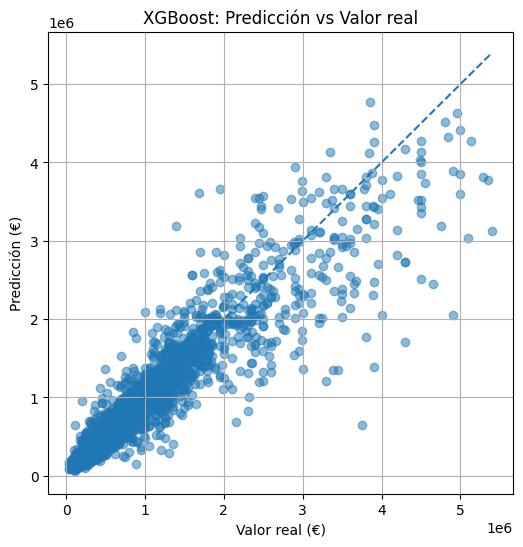

In [140]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)

# Línea ideal (predicción perfecta)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Valor real (€)")
plt.ylabel("Predicción (€)")
plt.title("XGBoost: Predicción vs Valor real")

plt.grid(True)
plt.show()

### LightGBM

In [141]:
from lightgbm import LGBMRegressor


# Modelo base
lgbm = LGBMRegressor(
    random_state=99,
    n_jobs=-1,
    verbose=-1
)

# Espacio de búsqueda
param_dist_lgbm = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [-1, 5, 10, 15],
    'num_leaves': [20, 31, 50, 70],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

# Validación cruzada
cv = KFold(n_splits=10, shuffle=True, random_state=99)

# Random Search
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist_lgbm,
    n_iter=50,
    cv=cv,
    scoring='neg_mean_absolute_error',
    random_state=99,
    n_jobs=-1
)

# Log del target
y_train_log = np.log(y_train)

# Entrenamiento
random_search_lgbm.fit(X_train, y_train_log)

# Mejor modelo
best_lgbm = random_search_lgbm.best_estimator_

# Predicción (invertir log)
y_pred_lgbm = np.exp(best_lgbm.predict(X_test))

# Métricas
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mape_lgbm = np.mean(np.abs((y_test - y_pred_lgbm) / y_test)) * 100


# Resultados
print("Mejores parámetros:", random_search_lgbm.best_params_)
print("MAE:", mae_lgbm)
print("RMSE:", rmse_lgbm)
print("R2:", r2_lgbm)
print("MAPE:", mape_lgbm)

Mejores parámetros: {'subsample': 0.8, 'num_leaves': 70, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
MAE: 156111.97483850224
RMSE: 301513.7826869573
R2: 0.8709903624715608
MAPE: 21.027612139982775


APLICAMOS STACKING

In [143]:
from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor




# Modelos base
estimators = [
    ('extratrees', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        max_features=1.0,
        min_samples_leaf=1,
        random_state=99
    )),
    
    ('xgb', XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=8,
        subsample=1.0,
        colsample_bytree=0.6,
        min_child_weight=5,
        gamma=0,
        random_state=99
    )),
    
    ('lgbm', LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=70,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.6,
        min_child_samples=10,
        random_state=99,
        verbose=-1
    )),
    
    ('knn', KNeighborsRegressor(
        n_neighbors=9,
        weights='distance',
        p=1
    ))
]

# Meta-modelo
final_estimator = Ridge(alpha=1.0)

# Stacking
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=10,
    n_jobs=-1
)

#aplicamos LOG
y_train_log = np.log(y_train)

# Entrenar -> Necesario que X esté normalizado por el uso de KNN
stacking_model.fit(X_train_final, y_train_log)

# Predecir
y_pred_stack = stacking_model.predict(X_test_final)

#Deshacer LOG
y_pred = np.exp(y_pred_stack)


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {rmse:,.0f} €")
print(f"R²: {r2:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE: 150,169 €
RMSE: 293,486 €
R²: 0.878
MAPE: 20.21%


GRAFICOS DE PREDDCION SEGÚN STACKING

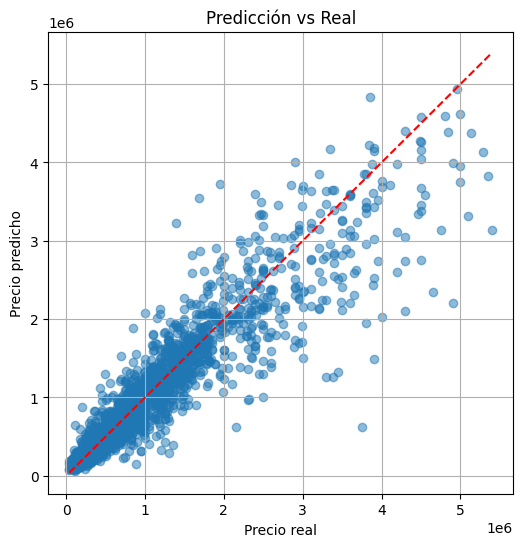

In [170]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Predicción vs Real")
plt.grid(True)
plt.show()

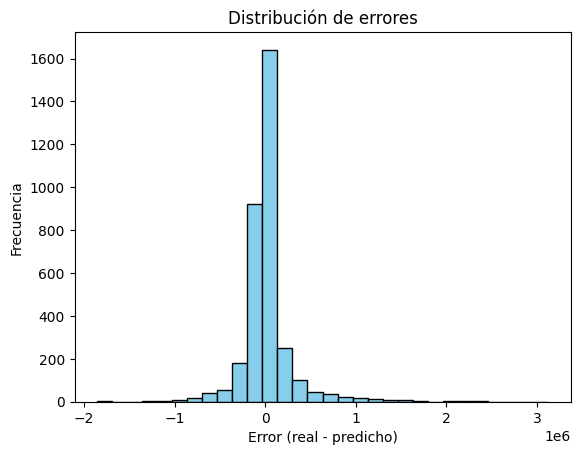

In [171]:
errors = y_test - y_pred
plt.hist(errors, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de errores")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.show()

In [176]:
import plotly.express as px

# Datos
data = {
    "Modelo": [
        "Regresión Lineal","Regresión Polinómica","Ridge","Lasso","KNN",
        "Árbol de decisión","Random Forest","Bagging Regressor","Extra Trees",
        "AdaBoost","Gradient Boosting","XGBoost","LightGBM","Stacking"
    ],
    "MAE": [299026,210136,299014,299026,180436,208694,155965,154314,151620,264706,168032,153038,156112,150169],
    "RMSE": [462147,358324,462144,462147,348863,375147,313500,311032,303002,497034,317758,300364,301514,293486],
    "R2": [0.7,0.82,0.7,0.7,0.83,0.8,0.861,0.863,0.87,0.649,0.857,0.872,0.871,0.878]
}

df = pd.DataFrame(data)

# Clasificación de modelos (para color)
def tipo_modelo(modelo):
    if modelo in ["Regresión Lineal", "Regresión Polinómica", "Ridge", "Lasso"]:
        return "Lineales"
    elif modelo in ["KNN"]:
        return "Instance-based"
    elif modelo in ["Árbol de decisión"]:
        return "Árbol"
    elif modelo in ["Random Forest", "Bagging Regressor", "Extra Trees"]:
        return "Bagging"
    elif modelo in ["AdaBoost", "Gradient Boosting", "XGBoost", "LightGBM"]:
        return "Boosting"
    elif modelo in ["Stacking"]:
        return "Ensemble"
    else:
        return "Otros"

df["Tipo"] = df["Modelo"].apply(tipo_modelo)

# Bubble chart
fig = px.scatter(
    df,
    x="MAE",
    y="R2",
    size="RMSE",
    color="Tipo",
    hover_name="Modelo",
    size_max=60,
    title="📊 Comparación de Modelos (MAE vs R² vs RMSE)",
)

# Invertir eje X → mejor MAE a la derecha
fig.update_layout(
    xaxis=dict(autorange="reversed", title="MAE (€) → menor es mejor"),
    yaxis=dict(title="R² → mayor es mejor"),
    legend_title="Tipo de modelo",
)

# Mejorar estética
fig.update_traces(marker=dict(opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

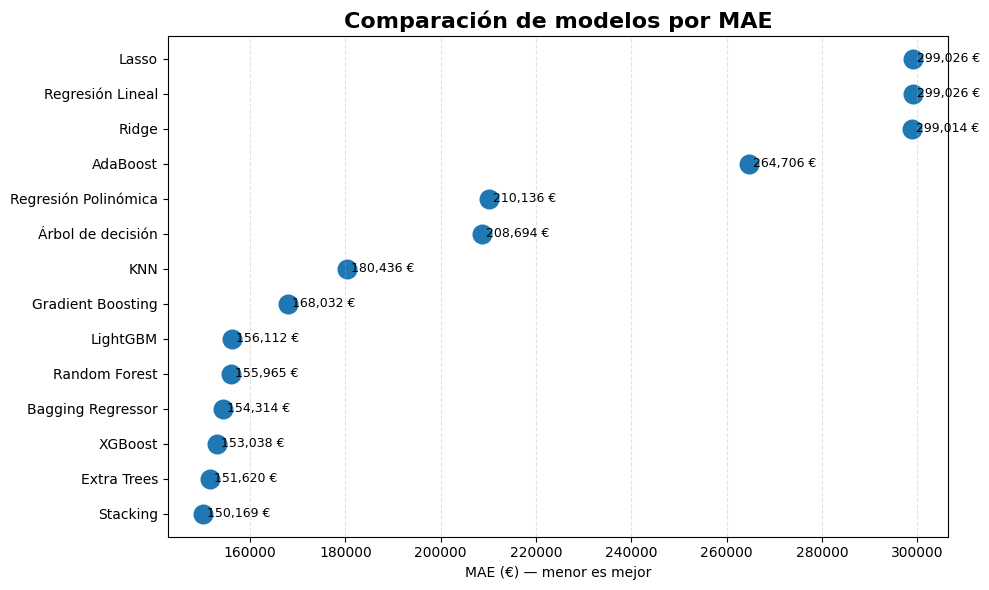

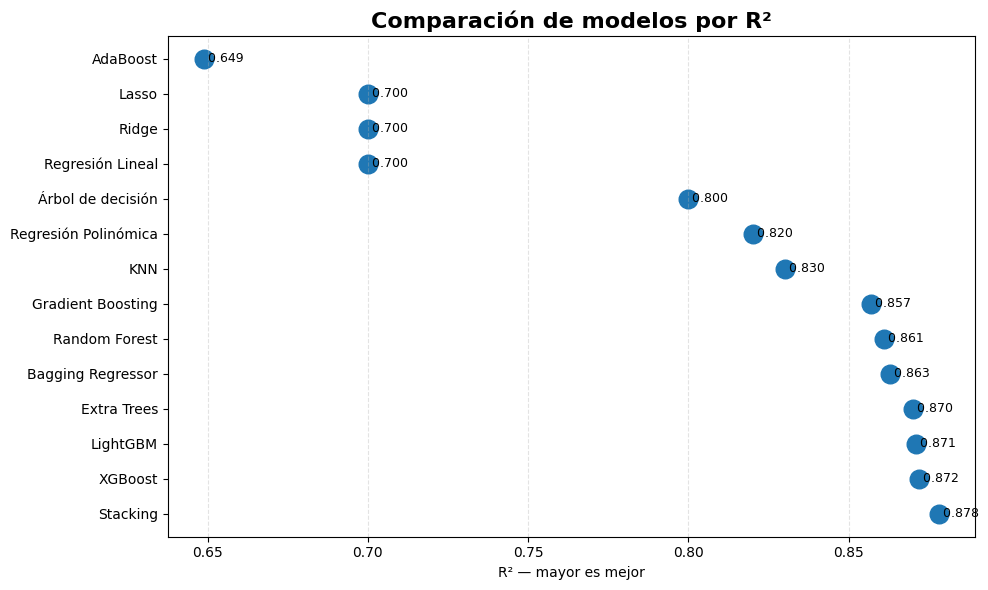

In [177]:
data = {
    "Modelo": [
        "Regresión Lineal","Regresión Polinómica","Ridge","Lasso","KNN",
        "Árbol de decisión","Random Forest","Bagging Regressor","Extra Trees",
        "AdaBoost","Gradient Boosting","XGBoost","LightGBM","Stacking"
    ],
    "MAE": [299026,210136,299014,299026,180436,208694,155965,154314,151620,264706,168032,153038,156112,150169],
    "RMSE": [462147,358324,462144,462147,348863,375147,313500,311032,303002,497034,317758,300364,301514,293486],
    "R2": [0.7,0.82,0.7,0.7,0.83,0.8,0.861,0.863,0.87,0.649,0.857,0.872,0.871,0.878]
}

df = pd.DataFrame(data)

# =========================
# 1. DOT PLOT MAE
# =========================

df_mae = df.sort_values("MAE", ascending=True)

plt.figure(figsize=(10, 6))
plt.scatter(df_mae["MAE"], df_mae["Modelo"], s=180)

plt.title("Comparación de modelos por MAE", fontsize=16, weight="bold")
plt.xlabel("MAE (€) — menor es mejor")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.35)

for x, y in zip(df_mae["MAE"], df_mae["Modelo"]):
    plt.text(x, y, f" {x:,.0f} €", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("grafico_mae.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================
# 2. DOT PLOT R²
# =========================

df_r2 = df.sort_values("R2", ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(df_r2["R2"], df_r2["Modelo"], s=180)

plt.title("Comparación de modelos por R²", fontsize=16, weight="bold")
plt.xlabel("R² — mayor es mejor")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.35)

for x, y in zip(df_r2["R2"], df_r2["Modelo"]):
    plt.text(x, y, f" {x:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("grafico_r2.png", dpi=300, bbox_inches="tight")
plt.show()